In [74]:
import pandas as pd
df = pd.read_csv('indian-coffee-all-responses (1).csv')

In [75]:
df.shape
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 11072 entries, 0 to 11071
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   respondentId         11000 non-null  str    
 1   source               11072 non-null  str    
 2   age                  11066 non-null  float64
 3   gender               11070 non-null  str    
 4   city                 11069 non-null  str    
 5   occupation           11069 non-null  str    
 6   monthlyIncome        11034 non-null  str    
 7   coffeeFrequency      11072 non-null  str    
 8   preferredCoffeeType  11062 non-null  str    
 9   preferredBrand       11059 non-null  str    
 10  monthlyCoffeeSpend   11059 non-null  str    
 11  purchaseLocation     11056 non-null  str    
 12  purchaseMode         11062 non-null  str    
 13  priceSensitivity     11054 non-null  str    
 14  tastePreference      11060 non-null  str    
 15  brandLoyalty         11059 non-null  str    
 1

,respondentId,source,age,gender,city,occupation,monthlyIncome,coffeeFrequency,preferredCoffeeType,preferredBrand,...,purchaseLocation,purchaseMode,priceSensitivity,tastePreference,brandLoyalty,willingnessToTry,preferredPriceRange,purchaseIntention,email,createdAt
count,11000,11072,11066.000000,11070,11069,11069,11034,11072,11062,11059,...,11056,11062,11054,11060,11059,11058,11058,11057,35,11072
unique,11000,2,NaN,7,42,32,1158,9,14,36,...,39,6,7,18,7,9,9,7,35,85
top,INDCOF07205,csv_import,NaN,Male,Delhi,Private Sector Employee,27500,3-4 times/week,Instant Coffee,Nescafé,...,Supermarket/Grocery Store,Offline,Medium,Balanced,Medium,Likely,₹201–350,High,abc@gmail.com,Wed Sep 02 2026 13:16:37 GMT+0530 (India Stand...
freq,1,11000,NaN,6099,1076,2379,187,3090,3338,3162,...,2878,6932,5283,3932,5259,4208,3411,4992,1,1000
mean,NaN,NaN,30.487439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,8.422340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
df.isnull().sum()

respondentId              72
source                     0
age                        6
gender                     2
city                       3
occupation                 3
monthlyIncome             38
coffeeFrequency            0
preferredCoffeeType       10
preferredBrand            13
monthlyCoffeeSpend        13
purchaseLocation          16
purchaseMode              10
priceSensitivity          18
tastePreference           12
brandLoyalty              13
willingnessToTry          14
preferredPriceRange       14
purchaseIntention         15
email                  11037
createdAt                  0
dtype: int64

# *EDA*

Shape: (11072, 30)

Columns:
['respondentId', 'source', 'age', 'gender', 'city', 'occupation', 'monthlyIncome', 'coffeeFrequency', 'preferredCoffeeType', 'preferredBrand', 'monthlyCoffeeSpend', 'purchaseLocation', 'purchaseMode', 'priceSensitivity', 'tastePreference', 'brandLoyalty', 'willingnessToTry', 'preferredPriceRange', 'purchaseIntention', 'email', 'createdAt', 'monthlyIncome_numeric', 'monthlyCoffeeSpend_numeric', 'age_group', 'priceSensitivity_encoded', 'brandLoyalty_encoded', 'willingnessToTry_encoded', 'purchaseIntention_encoded', 'response_date', 'response_month']

Data Types:
respondentId                      str
source                            str
age                           float64
gender                            str
city                              str
occupation                        str
monthlyIncome                     str
coffeeFrequency                   str
preferredCoffeeType               str
preferredBrand                    str
monthlyCoffeeSpend      

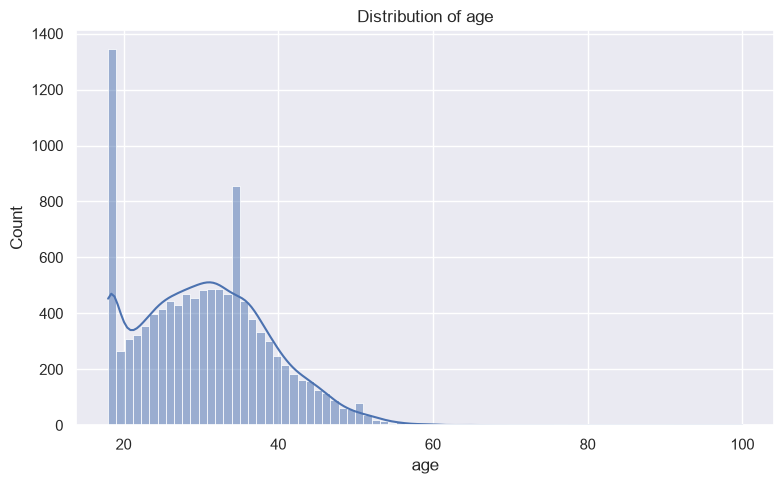

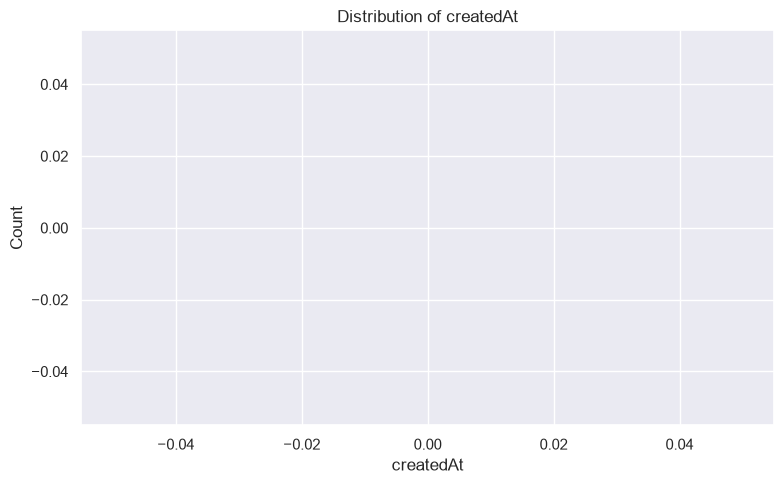

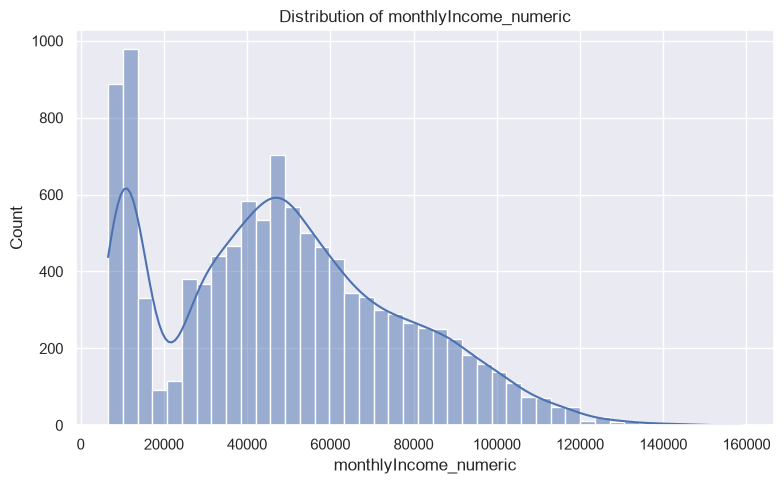

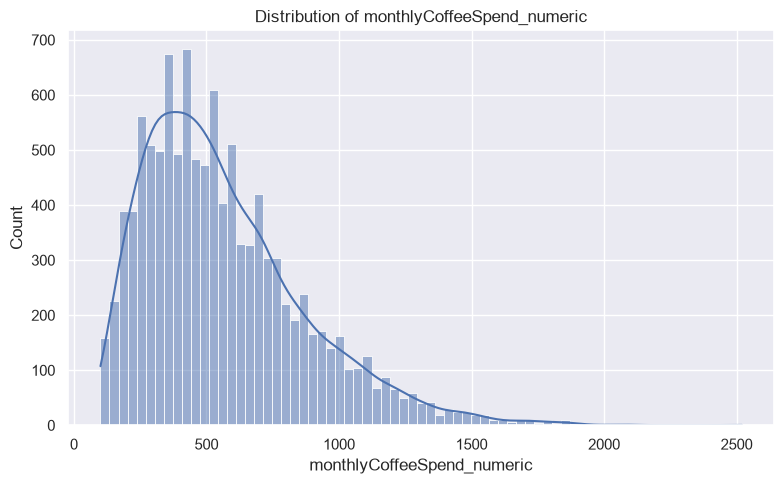

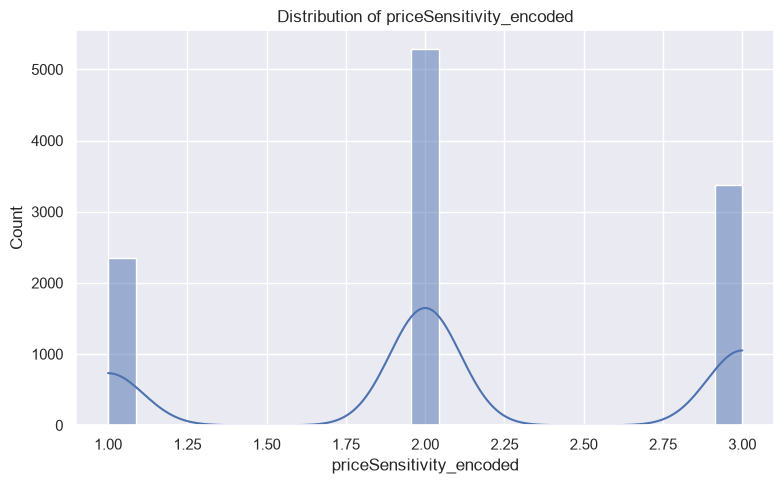

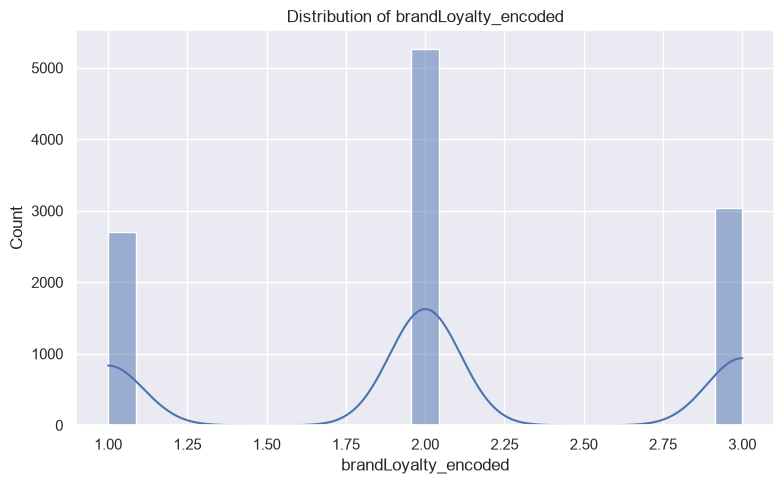

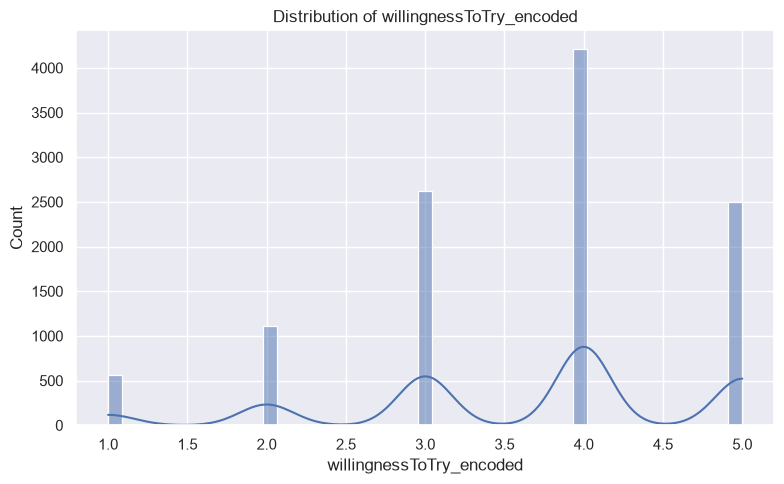

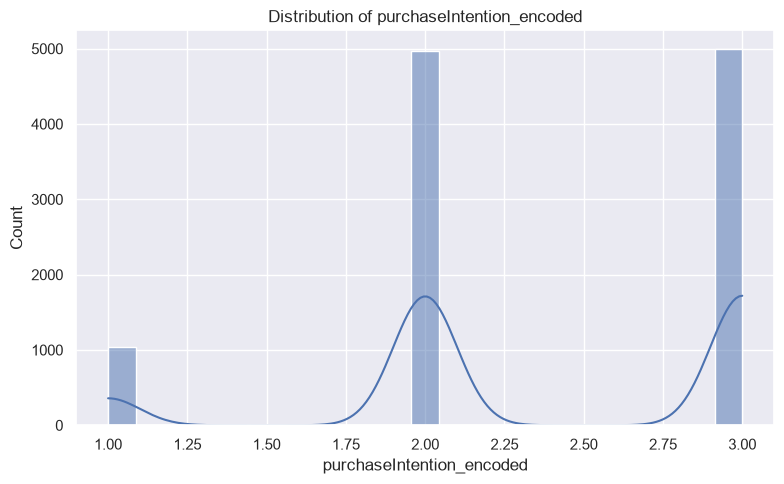

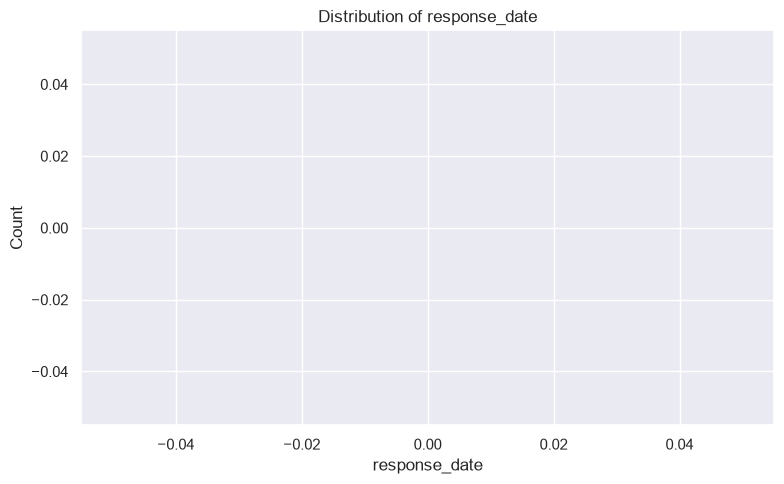

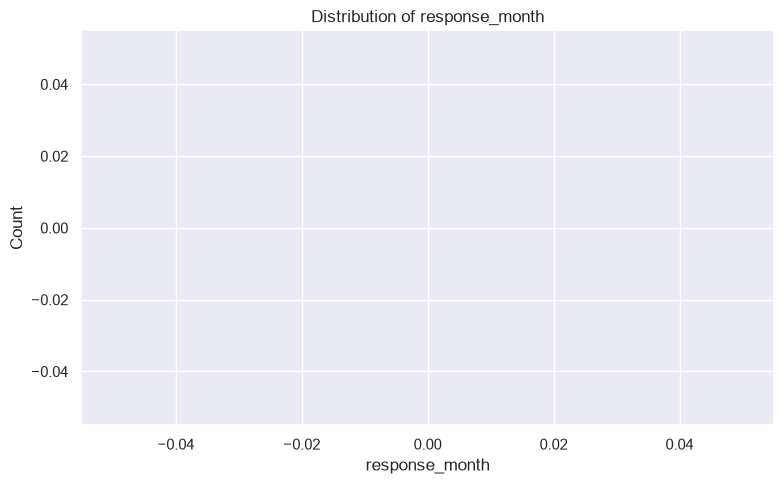

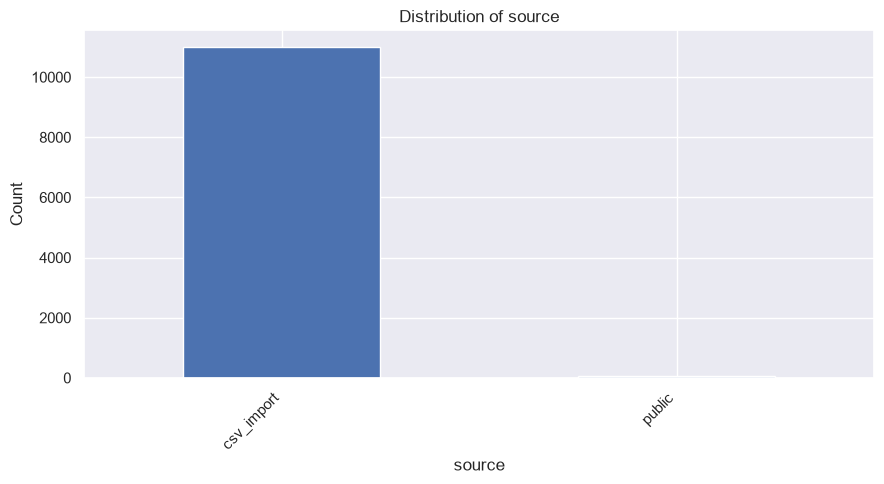

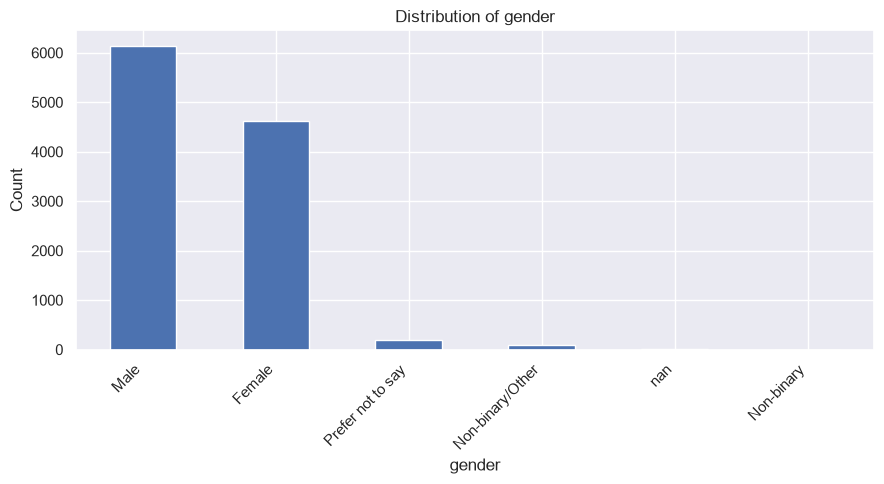

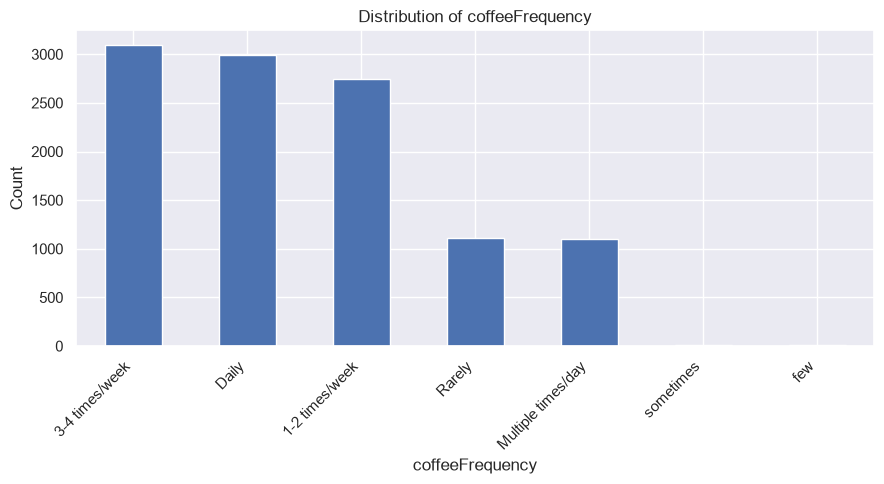

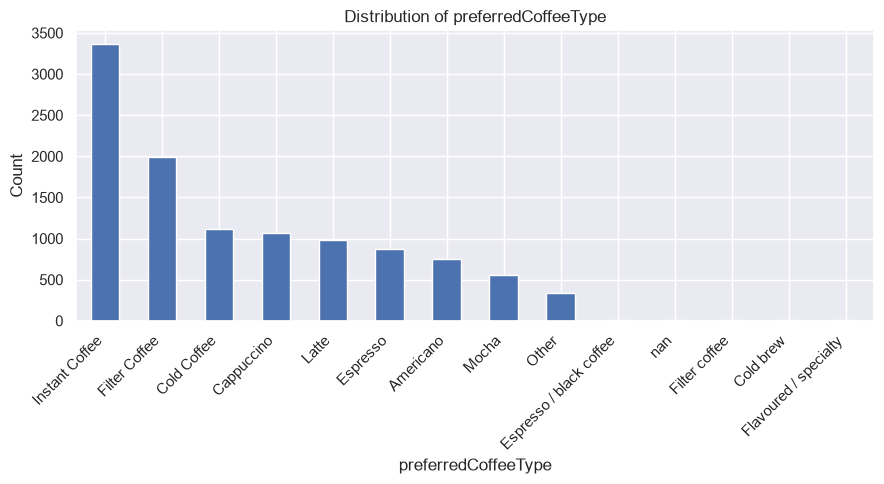

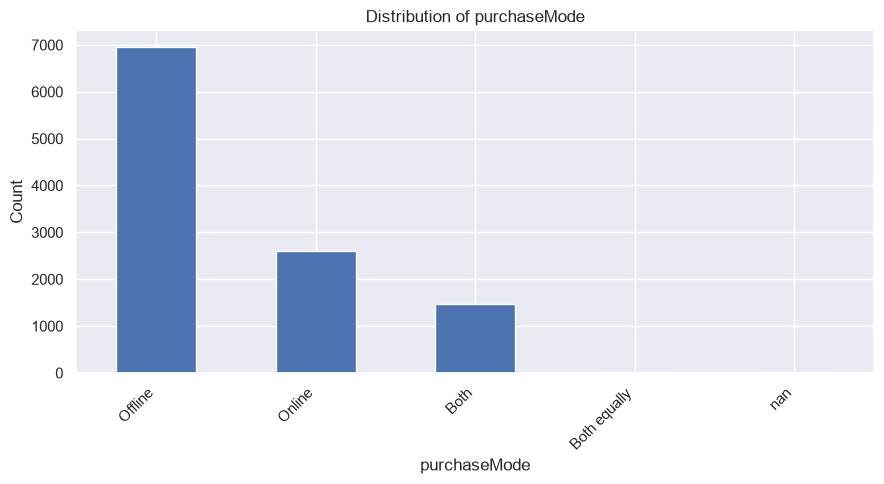

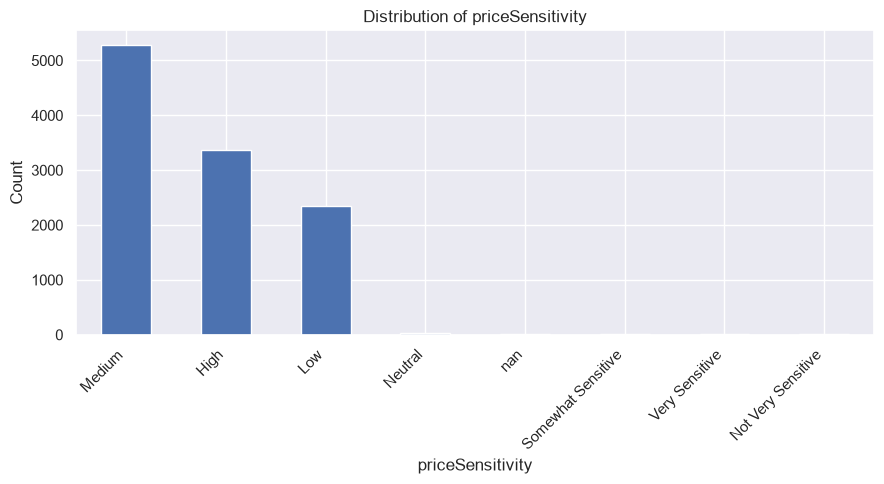

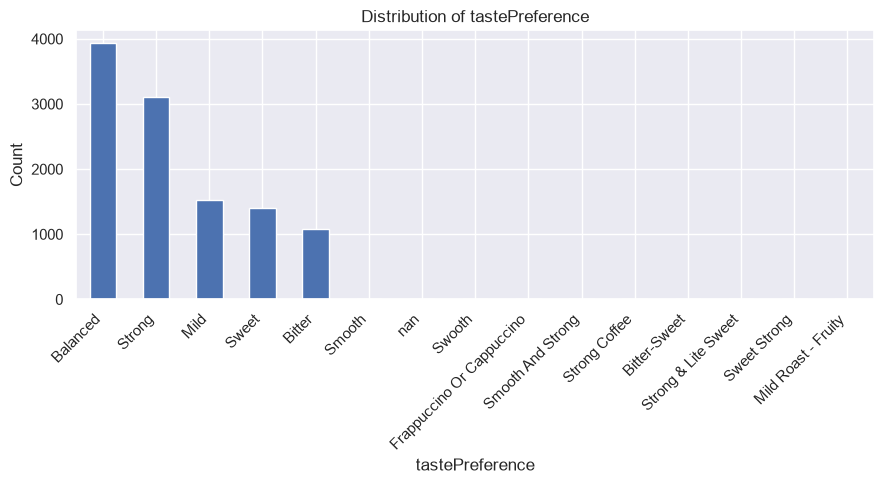

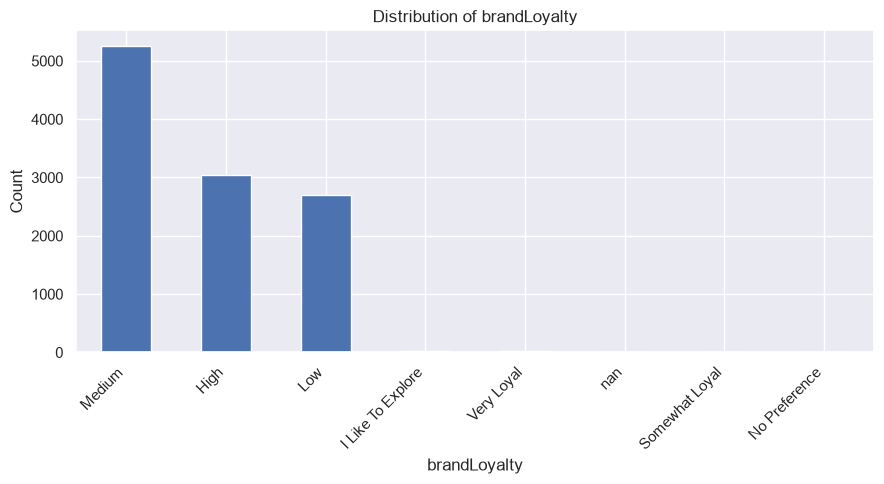

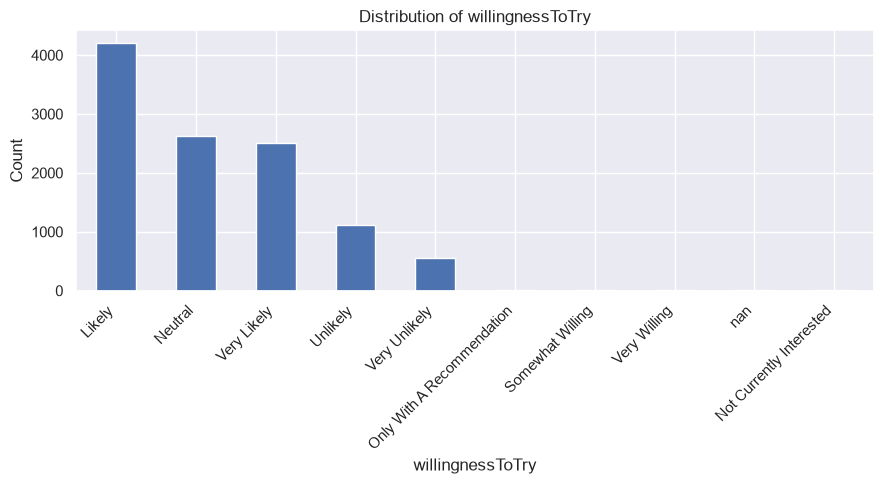

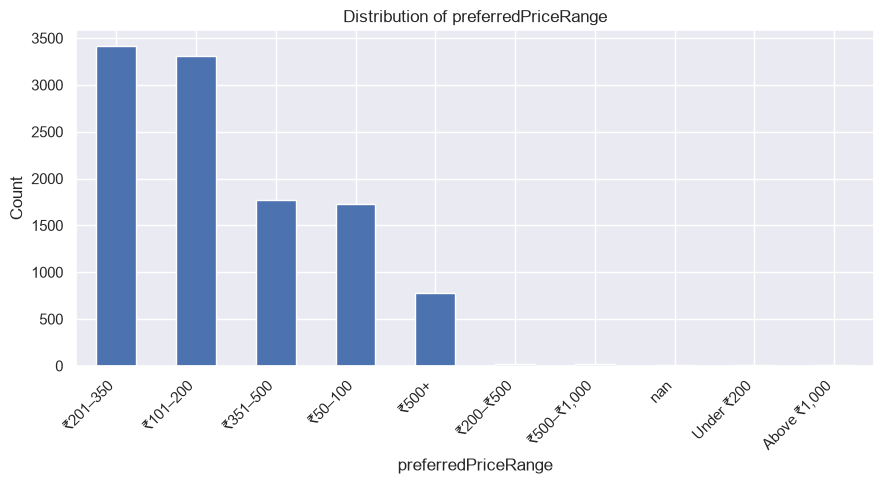

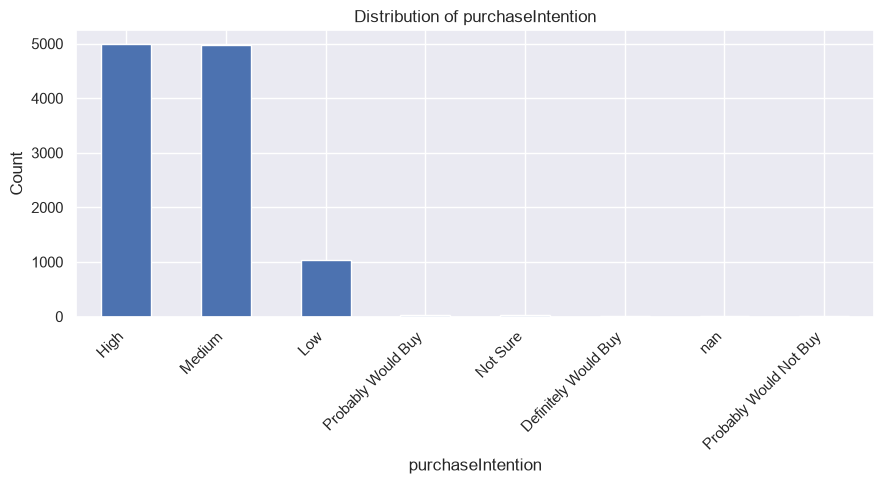

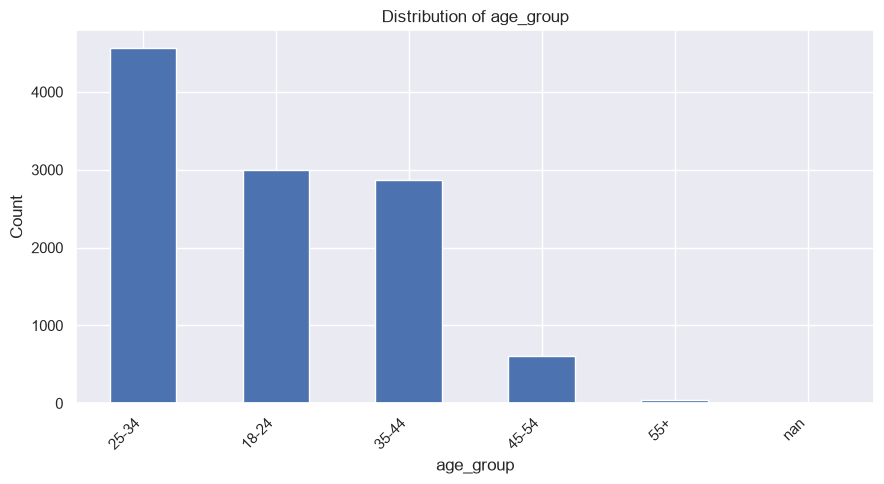

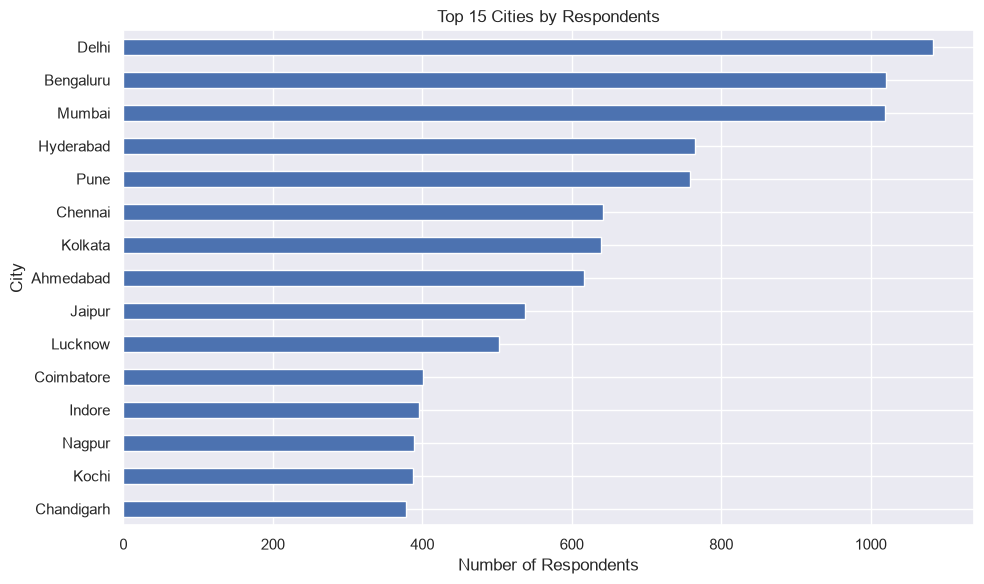

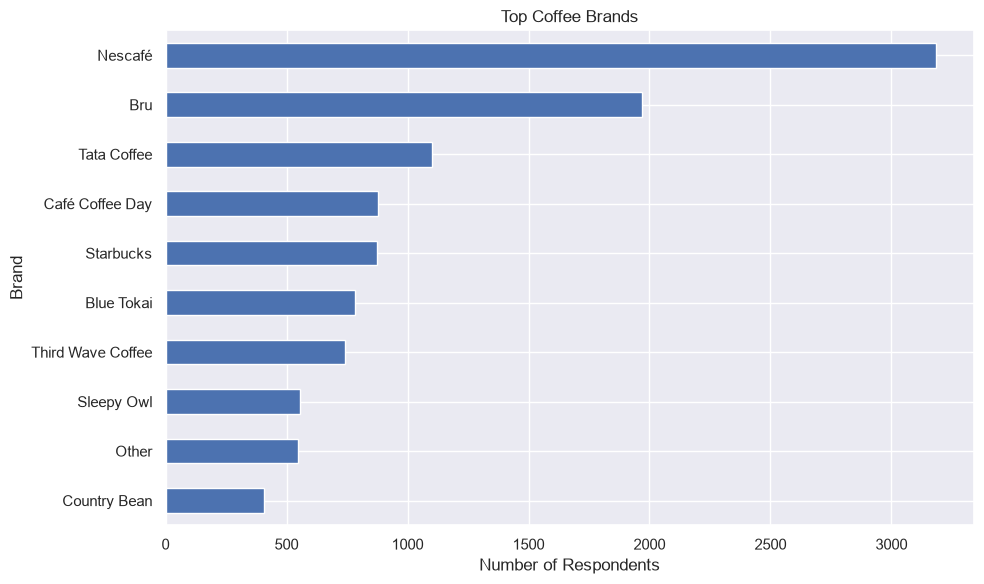

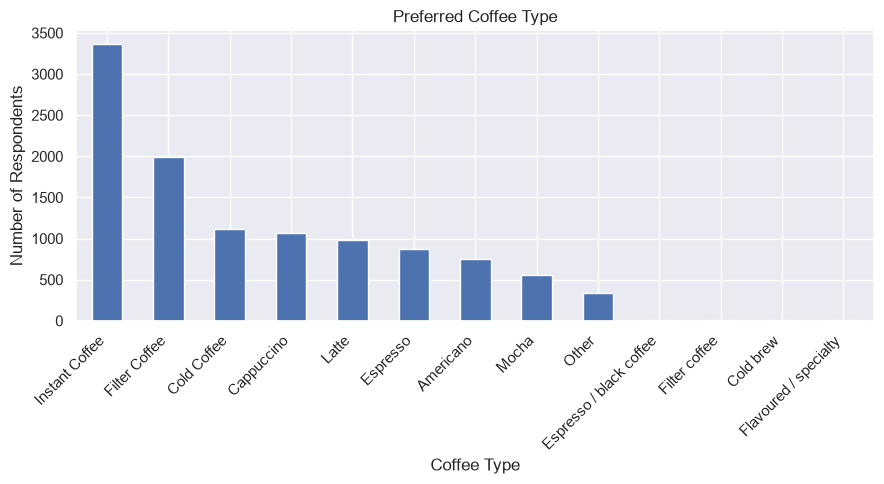

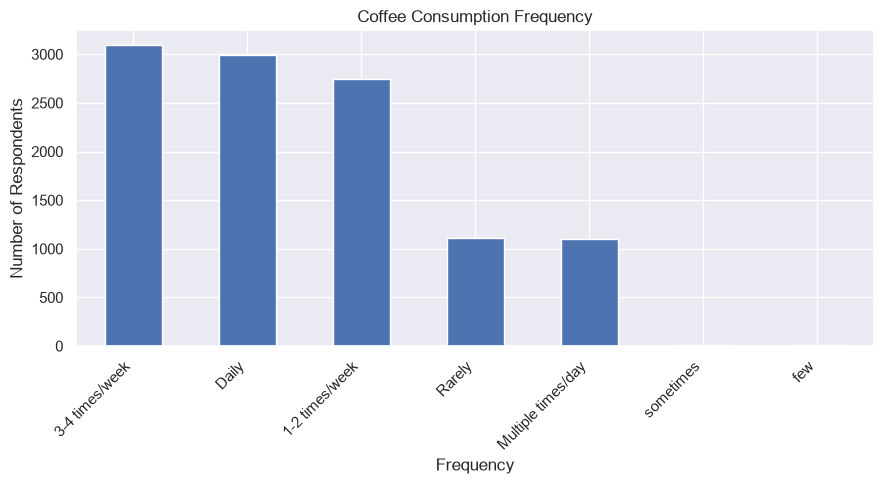

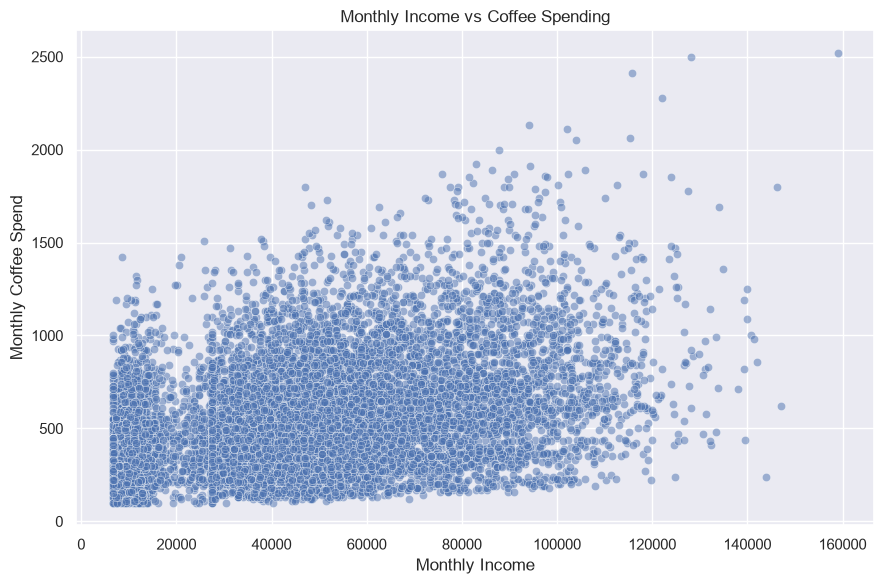

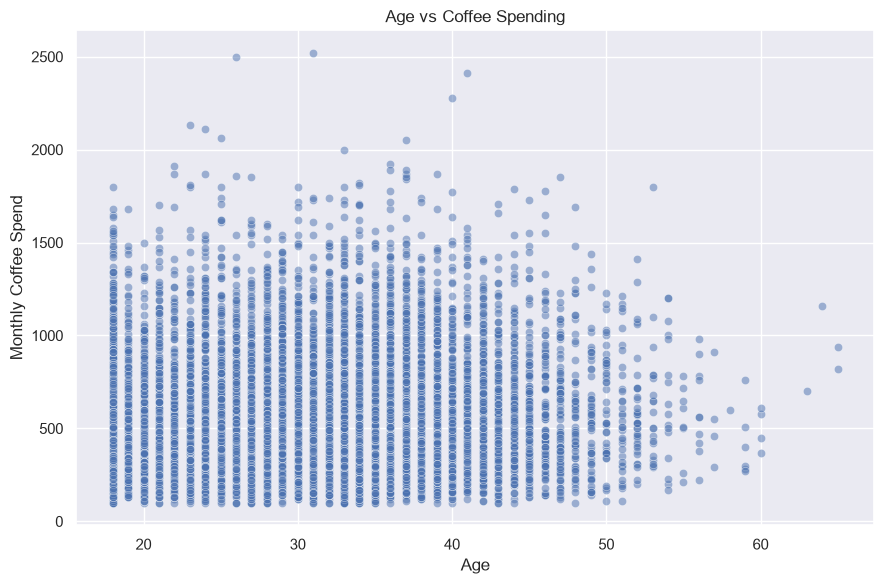

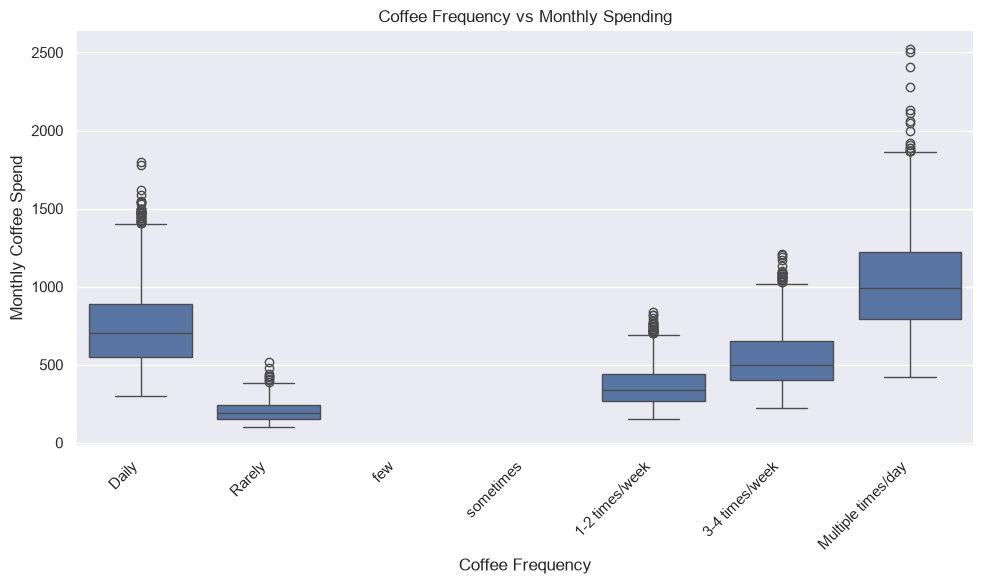

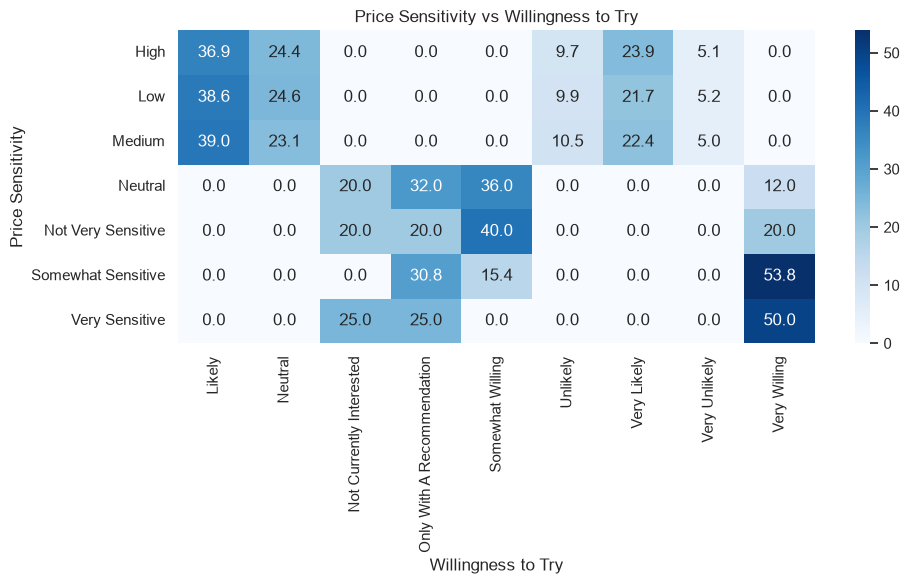

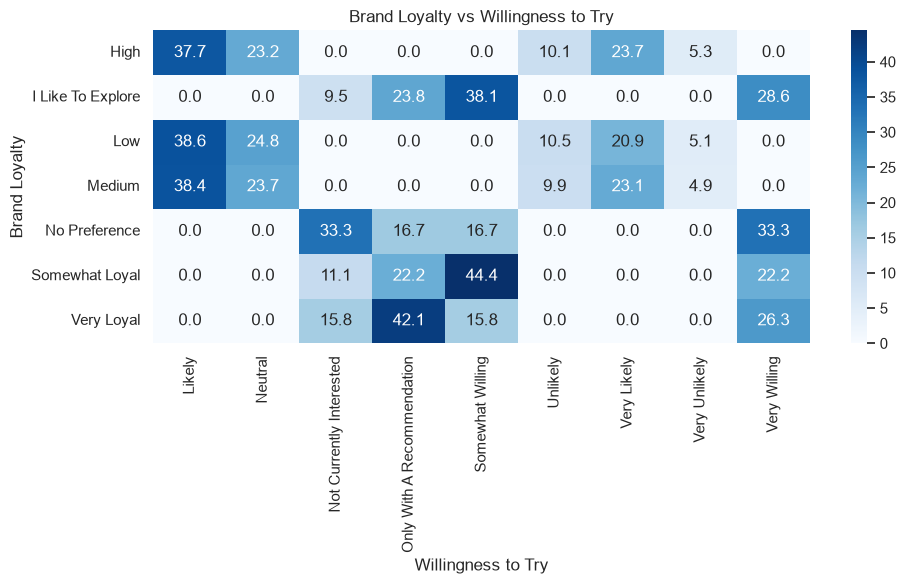

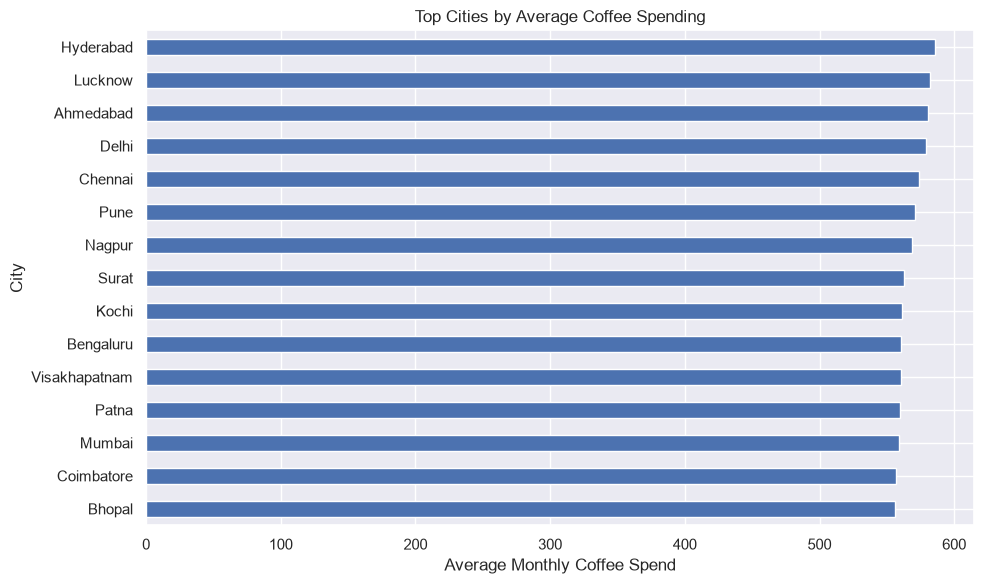

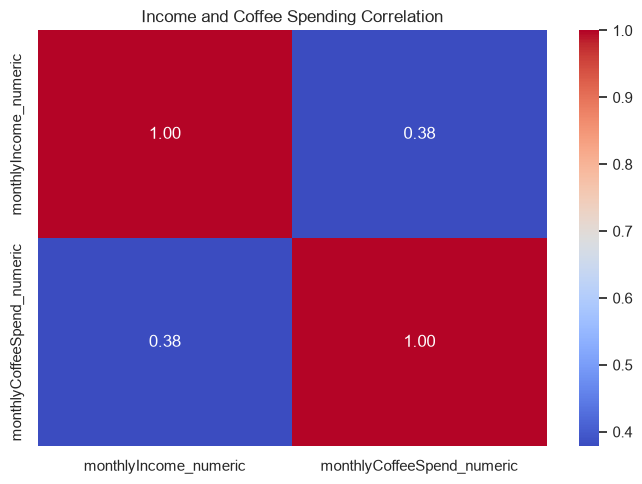

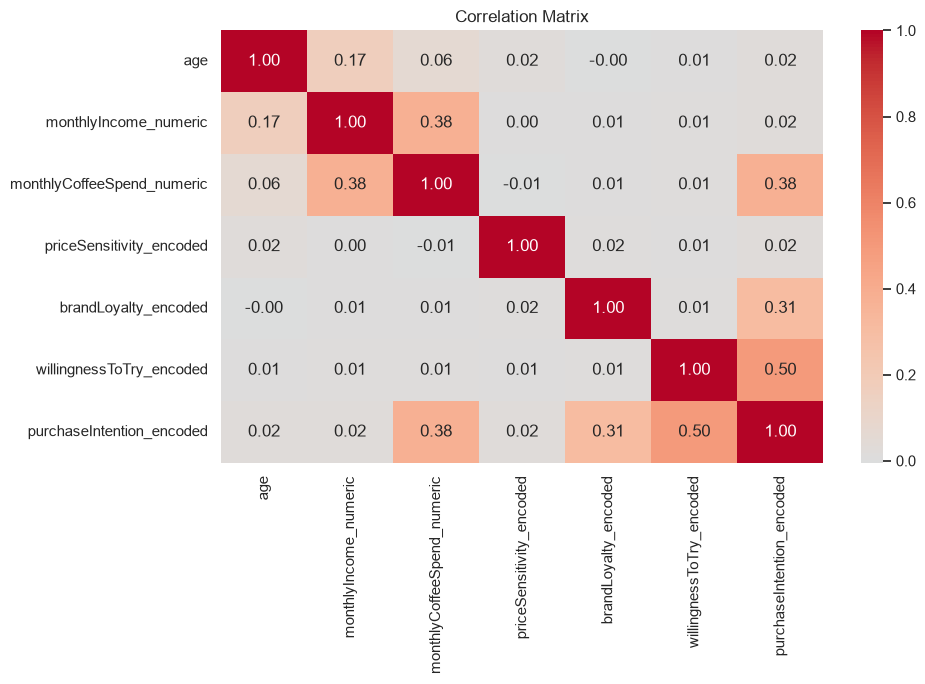


EDA completed.
Output saved to: \content\eda


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Updated path to match the output from the previous cleaning step
INPUT_FILE = "/content/data/processed/coffee_cleaned.csv"
OUTPUT_DIR = Path("/content/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"File not found at {INPUT_FILE}. Using the 'df' variable from memory instead.")
    # df is already in memory from the previous cell

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDescriptive Statistics:")
print(df.describe(include="all").T)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{col}_distribution.png", dpi=300)
    plt.show()
    plt.close()

for col in categorical_cols:
    if df[col].nunique(dropna=True) <= 20:
        plt.figure(figsize=(9, 5))
        df[col].value_counts(dropna=False).plot(kind="bar")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"{col}_distribution.png", dpi=300)
        plt.show()
        plt.close()

if "city" in df.columns:
    city_counts = df["city"].value_counts().head(15)

    plt.figure(figsize=(10, 6))
    city_counts.sort_values().plot(kind="barh")
    plt.title("Top 15 Cities by Respondents")
    plt.xlabel("Number of Respondents")
    plt.ylabel("City")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "top_cities.png", dpi=300)
    plt.show()
    plt.close()

if "preferredBrand" in df.columns:
    brand_counts = df["preferredBrand"].value_counts()

    plt.figure(figsize=(10, 6))
    brand_counts.head(10).sort_values().plot(kind="barh")
    plt.title("Top Coffee Brands")
    plt.xlabel("Number of Respondents")
    plt.ylabel("Brand")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "top_brands.png", dpi=300)
    plt.show()
    plt.close()

if "preferredCoffeeType" in df.columns:
    plt.figure(figsize=(9, 5))
    df["preferredCoffeeType"].value_counts().plot(kind="bar")
    plt.title("Preferred Coffee Type")
    plt.xlabel("Coffee Type")
    plt.ylabel("Number of Respondents")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "coffee_type.png", dpi=300)
    plt.show()
    plt.close()

if "coffeeFrequency" in df.columns:
    plt.figure(figsize=(9, 5))
    df["coffeeFrequency"].value_counts().plot(kind="bar")
    plt.title("Coffee Consumption Frequency")
    plt.xlabel("Frequency")
    plt.ylabel("Number of Respondents")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "coffee_frequency.png", dpi=300)
    plt.show()
    plt.close()

if "monthlyIncome_numeric" in df.columns and "monthlyCoffeeSpend_numeric" in df.columns:
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=df,
        x="monthlyIncome_numeric",
        y="monthlyCoffeeSpend_numeric",
        alpha=0.5
    )
    plt.title("Monthly Income vs Coffee Spending")
    plt.xlabel("Monthly Income")
    plt.ylabel("Monthly Coffee Spend")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "income_vs_spending.png", dpi=300)
    plt.show()
    plt.close()

if "age" in df.columns and "monthlyCoffeeSpend_numeric" in df.columns:
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=df,
        x="age",
        y="monthlyCoffeeSpend_numeric",
        alpha=0.5
    )
    plt.title("Age vs Coffee Spending")
    plt.xlabel("Age")
    plt.ylabel("Monthly Coffee Spend")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "age_vs_spending.png", dpi=300)
    plt.show()
    plt.close()

if "coffeeFrequency" in df.columns and "monthlyCoffeeSpend_numeric" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x="coffeeFrequency",
        y="monthlyCoffeeSpend_numeric"
    )
    plt.title("Coffee Frequency vs Monthly Spending")
    plt.xlabel("Coffee Frequency")
    plt.ylabel("Monthly Coffee Spend")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "frequency_vs_spending.png", dpi=300)
    plt.show()
    plt.close()

if "priceSensitivity" in df.columns and "willingnessToTry" in df.columns:
    cross_tab = pd.crosstab(
        df["priceSensitivity"],
        df["willingnessToTry"],
        normalize="index"
    ) * 100

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        cross_tab,
        annot=True,
        fmt=".1f",
        cmap="Blues"
    )
    plt.title("Price Sensitivity vs Willingness to Try")
    plt.xlabel("Willingness to Try")
    plt.ylabel("Price Sensitivity")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "price_vs_willingness.png", dpi=300)
    plt.show()
    plt.close()

if "brandLoyalty" in df.columns and "willingnessToTry" in df.columns:
    cross_tab = pd.crosstab(
        df["brandLoyalty"],
        df["willingnessToTry"],
        normalize="index"
    ) * 100

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        cross_tab,
        annot=True,
        fmt=".1f",
        cmap="Blues"
    )
    plt.title("Brand Loyalty vs Willingness to Try")
    plt.xlabel("Willingness to Try")
    plt.ylabel("Brand Loyalty")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "loyalty_vs_willingness.png", dpi=300)
    plt.show()
    plt.close()

if "city" in df.columns and "monthlyCoffeeSpend_numeric" in df.columns:
    city_spending = (
        df.groupby("city")["monthlyCoffeeSpend_numeric"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    city_spending["mean"].sort_values().plot(kind="barh")
    plt.title("Top Cities by Average Coffee Spending")
    plt.xlabel("Average Monthly Coffee Spend")
    plt.ylabel("City")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "city_average_spending.png", dpi=300)
    plt.show()
    plt.close()

if "monthlyIncome_numeric" in df.columns and "monthlyCoffeeSpend_numeric" in df.columns:
    correlation_data = df[
        ["monthlyIncome_numeric", "monthlyCoffeeSpend_numeric"]
    ].corr()

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        correlation_data,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )
    plt.title("Income and Coffee Spending Correlation")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "income_spending_correlation.png", dpi=300)
    plt.show()
    plt.close()

encoded_cols = [
    col for col in [
        "age",
        "monthlyIncome_numeric",
        "monthlyCoffeeSpend_numeric",
        "priceSensitivity_encoded",
        "brandLoyalty_encoded",
        "willingnessToTry_encoded",
        "purchaseIntention_encoded"
    ]
    if col in df.columns
]

if len(encoded_cols) >= 2:
    correlation_matrix = df[encoded_cols].corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "correlation_matrix.png", dpi=300)
    plt.show()
    plt.close()

summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    ),
    "Unique_Values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

summary.to_csv(
    OUTPUT_DIR / "eda_summary.csv",
    index=False
)

print("\nEDA completed.")
print(f"Output saved to: {OUTPUT_DIR}")

# *Cleaning*


In [78]:
import pandas as pd
df = pd.read_csv('indian-coffee-all-responses (1).csv')

In [79]:
df.isnull().sum()

respondentId              72
source                     0
age                        6
gender                     2
city                       3
occupation                 3
monthlyIncome             38
coffeeFrequency            0
preferredCoffeeType       10
preferredBrand            13
monthlyCoffeeSpend        13
purchaseLocation          16
purchaseMode              10
priceSensitivity          18
tastePreference           12
brandLoyalty              13
willingnessToTry          14
preferredPriceRange       14
purchaseIntention         15
email                  11037
createdAt                  0
dtype: int64

In [80]:
df=df.drop(columns=["createdAt","email","respondentId","source"])

In [81]:
df['age'] = df['age'].fillna(df['age'].mean())

In [82]:
import re
import numpy as np

income_map = {
    "Below ₹25,000": 12500,
    "₹25,000–₹50,000": 37500,
    "₹50,000–₹1,00,000": 75000,
    "Above ₹1,00,000": 125000
}

def to_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in income_map:
        return income_map[x]
    return float(re.sub(r"[₹,]", "", x))

df["monthlyIncome"] = df["monthlyIncome"].apply(to_numeric)

In [83]:
df['monthlyIncome'] = df['monthlyIncome'].fillna(df['monthlyIncome'].mean())

In [84]:
income_map1 = {
    "Under ₹500": 490,
    "₹500–₹1,000": 700,
    "₹1,000–₹2,500": 2400,
    "Above ₹2,500": 4000
}

def to_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in income_map1:
        return income_map1[x]
    return float(re.sub(r"[₹,]", "", x))

df["monthlyCoffeeSpend"] = df["monthlyCoffeeSpend"].apply(to_numeric)

In [85]:
df['monthlyCoffeeSpend'] = df['monthlyCoffeeSpend'].fillna(df['monthlyCoffeeSpend'].mean())

In [86]:
income_map2 = {
   "₹50–100":90,
    "₹101–200":130,
    "Under ₹200": 150,
    "₹201–350":300,
    "₹351–500":450,
    "₹200–₹500": 400,
    "₹500–₹1,000": 950,
    "₹500+":700,
    "Above ₹1,000": 2000
}

def to_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in income_map2:
        return income_map2[x]
    return float(re.sub(r"[₹,]",r"[,+]", "", x))

df["preferredPriceRange"] = df["preferredPriceRange"].apply(to_numeric)
df['preferredPriceRange'] = df['preferredPriceRange'].fillna(df['preferredPriceRange'].mean())

In [87]:
value=["gender", 'city', 'occupation', 'preferredCoffeeType', 'preferredBrand',
       'purchaseLocation', 'purchaseMode',
       'priceSensitivity', 'tastePreference', 'brandLoyalty',
       'willingnessToTry', 'purchaseIntention']
for x in value:
  df[x]=df[x].fillna(df[x].mode()[0])
  pass

In [88]:
df=df.dropna()
df.isnull().sum()

age                    0
gender                 0
city                   0
occupation             0
monthlyIncome          0
coffeeFrequency        0
preferredCoffeeType    0
preferredBrand         0
monthlyCoffeeSpend     0
purchaseLocation       0
purchaseMode           0
priceSensitivity       0
tastePreference        0
brandLoyalty           0
willingnessToTry       0
preferredPriceRange    0
purchaseIntention      0
dtype: int64

In [89]:
df["willingnessToTry"]=df["willingnessToTry"].replace({"Likely":1,
                                                       "Very Likely":1,
                                                       "Unlikely":0,
                                                       "Very Unlikely":0,
                                                       "Somewhat willing":1,
                                                       "Very willing":1,
                                                       "Not currently interested":0,
                                                       "Only with a recommendation":0,
                                                       "Neutral":0})

In [90]:
df["preferredBrand"] = df["preferredBrand"].replace({
    "Nestle'": "Nescafé", "Nesscafe": "Nescafé", "nescafe": "Nescafé",
    "bru": "Bru", "Brew": "Bru", "Caffe Coffee Day": "Café Coffee Day",
    "BLUE TOKI": "Blue Tokai", "Blue tokai": "Blue Tokai",
    "third wave": "Third Wave Coffee", "davidoff": "Davidoff",
})
df["tastePreference"] = df["tastePreference"].replace({
    "Sweet Strong": "Strong", "Strong Coffee": "Strong",
    "Smooth And Strong": "Smooth", "Strong & Lite Sweet": "Strong",
    "Frappuccino Or Cappuccino": "Smooth", "Bitter-Sweet": "Bitter",
    "Mild Roast - Fruity": "Mild", "Swooth": "Smooth",
})
df["occupation"] = df["occupation"].replace({
    "Teacher": "Teacher/Professor", "Business": "Business Owner",
    "Engineering Student": "Student", "Farmer": "Other", "Employee": "IT Professional",
    "Engineer": "IT Professional", "Designer": "Other", "DESIGNER": "Other",
    "Buisness": "Business Owner", "Communication Professional": "Other",
    "Nurse": "Healthcare Professional", "On Bed": "Other", "HR": "Other",
    "Private employee": "IT Professional", "Sutdent": "Student",
    "Trainer": "Other", "employee": "Other", "student": "Student",
})
df["city"] = df["city"].replace({
    "delhi": "Delhi", "New delhi": "Delhi", "New Delhi": "Delhi",
    "noida": "Noida", "Greater noida": "Noida","Delhi":"Delhi","Noida":"Noida"
})

In [91]:
df = df.rename(columns={
    "age": "Age", "monthlyIncome": "Income", "monthlyCoffeeSpend": "Coffee_Spend",
    "preferredBrand": "Current_Brand", "priceSensitivity": "Price_Sensitivity",
    "tastePreference": "Premium_Preference", "purchaseLocation": "Product_Format",
    "willingnessToTry": "Will_Buy_New_Brand"})

In [92]:
df.value_counts("coffeeFrequency")
freq_order = {
    "Rarely": 0, "few": 0,"rarely":0,
    "1-2 times/week": 1, "sometimes": 1,
    "3-4 times/week": 2,
    "Daily": 3,
    "daily":3,
    "Multiple times/day": 4,
}
df["coffeeFrequency"] = df["coffeeFrequency"].map(freq_order)

df.value_counts("coffeeFrequency")
df["brandLoyalty"] = df["brandLoyalty"].map({
    "Low": 0, "No Preference": 0,
    "Medium": 1, "Somewhat Loyal": 1,
    "High": 2, "Very Loyal": 2, "I Like To Explore": 0,
})
df["brandLoyalty"] = df["brandLoyalty"].fillna(df["brandLoyalty"].mode()[0]).astype(int)



In [93]:
df['city']=df['city'].map({"Delhi":0,"New delhi":0,"New Delhi":0,"noida":1,"Greater noida":1,"Noida":1,"Bengaluru":2,
                           "Mumbai":3,"Hyderabad":4,"Pune":5,"Chennai":6,"Kolkata":16,"Ahmedabad":7,"Jaipur":8,"Lucknow":9,"Coimbatore":10,
                           "Indore":11,"Nagpur":12,"Ranchi":13,"Rohtak":14,"Kota":15,"Dwarka":0,"Dehradun":17,"Bihar":18,"Andman":19,"Araria":20,"Kanpur":21,
                           "Visakhapatnam":22,"Bhubaneswar":23,"Bhopal":24,'Kochi':25,"Chandigarh":26,"Patna":18,"Surat":28,"Jammu":27})

In [94]:
df.isnull().sum()
df=df.dropna()

In [95]:
df["occupation"]=df["occupation"].map({"Private Sector Employee":0,
"Student":1,"Student":1,"Engineering Student":1,
"IT Professional":2,
"Business Owner":3,"Business":3,"Buisness":3,
"Government Employee":4,
"Freelancer":5,
"Healthcare Professional":6,
"Teacher/Professor":7,
"Homemaker":8,
"Other":9,"Communication Professional":9,
"Nurse":9,
"DESIGNER":9,
"Employee":9})

In [96]:
df=df.drop(columns=["preferredCoffeeType","gender"])

df.value_counts("purchaseIntention")
df["purchaseIntention"]=df["purchaseIntention"].map({"High":1,"Definitely would buy":1,
                                                     "Low":0,"Not sure":0,"Probably would buy":2,
                                                     "Medium":2})

df.value_counts("purchaseMode")
df["purchaseMode"]=df["purchaseMode"].map({"Online":1,"Mostly online":1,
                                           "Offline":0,"Mostly offline":0,
                                           "Both equally":2,"Both":2})

In [97]:
df=pd.get_dummies(df,columns=["Price_Sensitivity","Premium_Preference","Product_Format","Current_Brand"])

In [98]:
df=df.dropna()
df=df.astype(int)

# *Customer Segmentation*


[[12500.   700.   950.]
 [12500.   700.   950.]
 [12500.   700.   400.]
 ...
 [25700.  1210.   700.]
 [42600.   550.   130.]
 [56000.   300.   300.]]


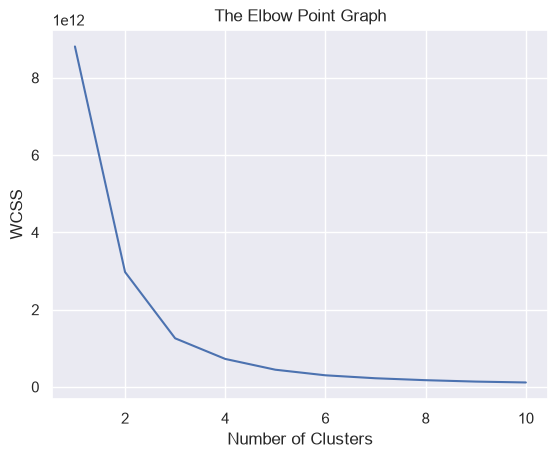

[1 1 1 ... 1 0 0]


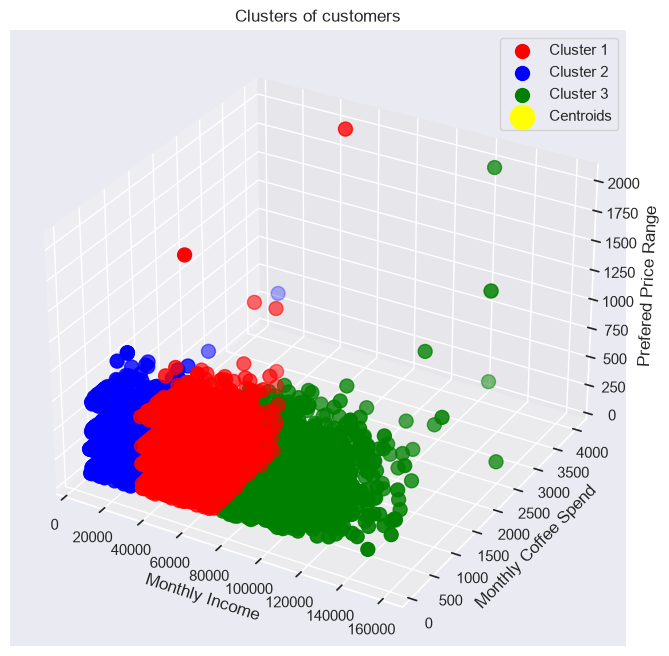

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

#Loading the dataset
customer_data = pd.read_csv('data/indian-coffee-all-responses final dataset.csv')

X = customer_data.iloc[:, [4, 8, 15]].values
print(X)

# Finding WCSS (Within-Cluster Sum of Squares) for different number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method to find the optimal number of clusters
sns.set()
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show() 

# Training the K-Means model on the dataset
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=0)

# Return a label for each data point based on the number of clusters
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans)

# Visualizing the clusters
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], X[y_kmeans == 0, 2], s = 100, c = 'red', label = 'Cluster 1')
ax.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], X[y_kmeans == 1, 2], s = 100, c = 'blue', label = 'Cluster 2')
ax.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], X[y_kmeans == 2, 2], s = 100, c = 'green', label = 'Cluster 3')

# Plotting the centroids of the clusters
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s = 300, c = 'yellow', label = 'Centroids')
ax.set_title('Clusters of customers')
ax.set_xlabel('Monthly Income')
ax.set_ylabel('Monthly Coffee Spend')
ax.set_zlabel('Prefered Price Range')
ax.legend()
plt.show()


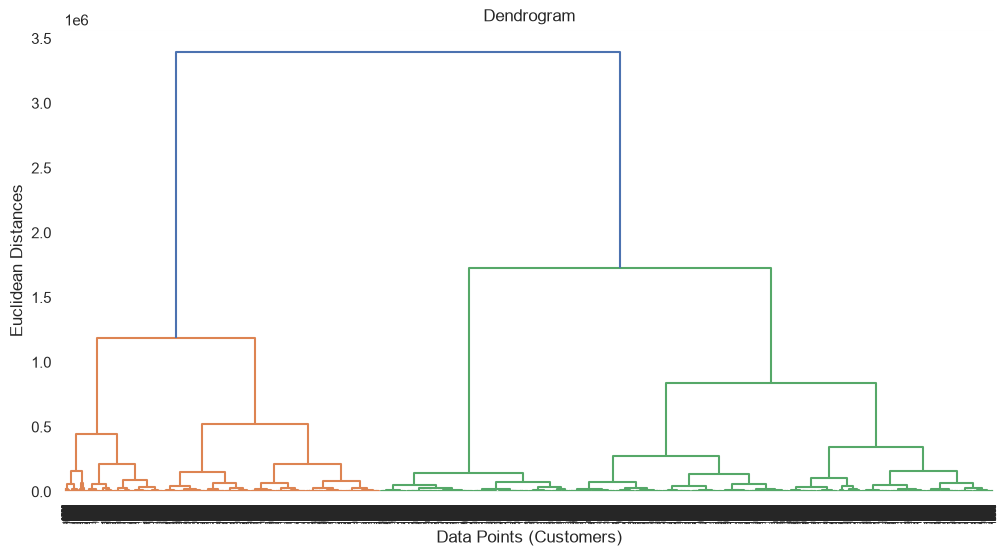

In [100]:
# Hierarchical Clustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Dendrogram
plt.figure(figsize=(12, 6))
plt.title("Dendrogram")

# Using Ward's method to minimize variance
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.xlabel('Data Points (Customers)')
plt.ylabel('Euclidean Distances')
plt.show()

In [101]:
from sklearn.cluster import AgglomerativeClustering

# Re-create X from the current 'df' to ensure consistent number of rows
# Based on the earlier K-Means clustering, the features were Monthly Income, Monthly Coffee Spend, and Preferred Price Range.
# These columns are 'Income', 'Coffee_Spend', and 'preferredPriceRange' in the cleaned 'df'.
X = df[['Income', 'Coffee_Spend', 'preferredPriceRange']].values

# Initialize and fit the model (using 2 clusters)
hc = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

# Predict cluster labels for each data point
y_hc = hc.fit_predict(X)

# Save the labels back to your dataframe
df['hierarchical_cluster'] = y_hc

print(df['hierarchical_cluster'].value_counts())

hierarchical_cluster
0    8389
1    2647
Name: count, dtype: int64


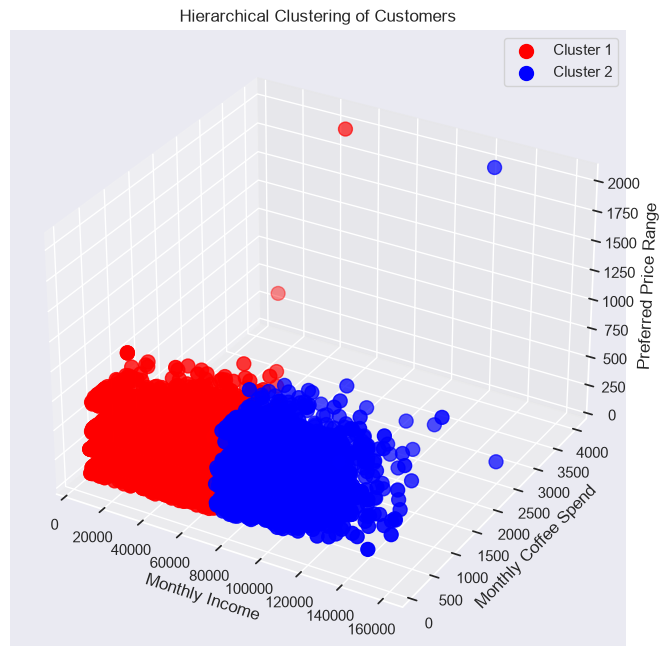

In [102]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# Plot each cluster with a different color/label
ax.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], X[y_hc == 0, 2], s=100, c='red', label='Cluster 1')
ax.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], X[y_hc == 1, 2], s=100, c='blue', label='Cluster 2')

ax.set_title('Hierarchical Clustering of Customers')
ax.set_xlabel('Monthly Income')
ax.set_ylabel('Monthly Coffee Spend')
ax.set_zlabel('Preferred Price Range')
ax.legend()
plt.show()

In [103]:
# K means Silhouette Score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Re-train K-Means on the currently active X (11,036 samples) to align shapes
kmeans_aligned = KMeans(n_clusters=3, init='k-means++', random_state=0)
y_kmeans_aligned = kmeans_aligned.fit_predict(X)

# Calculate the Silhouette Score with aligned data
score = silhouette_score(X, y_kmeans_aligned)
print("K-means Silhouette Score:", score)

K-means Silhouette Score: 0.590453164883026


In [104]:
# Hierarchical Clustering Silhouette Score
from sklearn.metrics import silhouette_score
score = silhouette_score(X, y_hc)
print(score)

0.5568769021406235


# *New Coffee Brand Adoption, Prediction*

In [105]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import xgboost as xgb

In [107]:
X = df.drop(columns=["Will_Buy_New_Brand"])
y = df["Will_Buy_New_Brand"].astype(int)

In [108]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [109]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
y_prob=model.predict_proba(X_test)[:,1]
print(y_prob)

Accuracy 0.605072463768116
[0.61754827 0.55986709 0.59564785 ... 0.62929479 0.6115994  0.60582473]


In [110]:
model=DecisionTreeClassifier(random_state=0)
model.fit(X_train,y_train)
y_pred_dt=model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred_dt))

Accuracy 0.6390398550724637


In [111]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=0,
)
model.fit(X_train,y_train)
y_pred_rf=model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred_rf))
y_prob_rf=model.predict_proba(X_test)[:,1]
print(y_prob)

Accuracy 0.7182971014492754
[0.61754827 0.55986709 0.59564785 ... 0.62929479 0.6115994  0.60582473]


In [112]:
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=0,
)

model.fit(
    X_train, y_train,
)

y_pred_xg = model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred_xg))
y_prob=model.predict_proba(X_test)[:,1]
print(y_prob)

Accuracy 0.75
[0.83296376 0.8190272  0.81457    ... 0.9067218  0.5458182  0.85555327]


In [113]:
model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)

model.fit(X_train,y_train)
y_pred_gb = model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred_gb))
y_prob_gb = model.predict_proba(X_test)[:,1]
print("Probability:",y_prob_gb)

Accuracy 0.7608695652173914
Probability: [0.81923311 0.80545955 0.73139482 ... 0.85565503 0.69233281 0.86354944]


Evalution

In [114]:
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score)

def evaluate_model(model_name,y_true,y_pred,y_probability=None):
  result = {"Model": model_name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred)}
  if y_probability is not None:
    result["ROC_AUC"] = roc_auc_score(y_true,y_probability)
  return result

In [115]:
results = []
results.append(evaluate_model("Logistic Regression",y_test,y_pred,y_prob))
results.append(evaluate_model("Random Forest",y_test,y_pred_rf,y_prob_rf))
results.append(evaluate_model("Gradient Boosting",y_test,y_pred_gb,y_prob_gb))

model_results = pd.DataFrame(results)

model_results.sort_values("F1",ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Gradient Boosting,0.760870,0.775580,0.851048,0.811563,0.798963
1,Random Forest,0.718297,0.717949,0.880240,0.790854,0.756033
0,Logistic Regression,0.605072,0.605072,1.000000,0.753950,0.783763


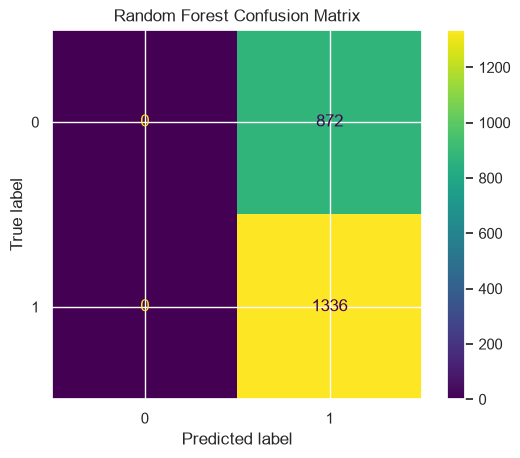

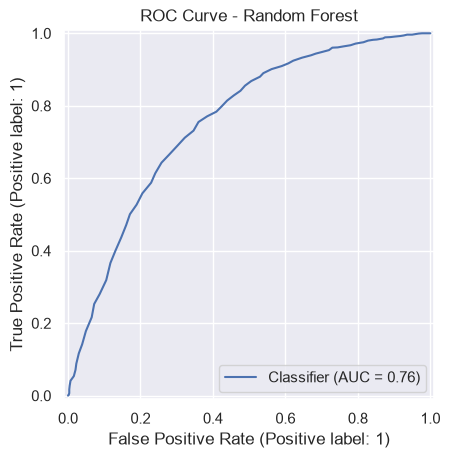

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test,y_prob_rf)

plt.title("ROC Curve - Random Forest")
plt.show()

# *Coffee Spending Prediction*

In [117]:
# IMPORTING LIBRARIES 

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

Feature Shape: (11036, 90)
Target Shape: (11036,)

Categorical Features:
[]

Numerical Features:
['Age', 'city', 'occupation', 'Income', 'coffeeFrequency', 'purchaseMode', 'brandLoyalty', 'Will_Buy_New_Brand', 'preferredPriceRange', 'purchaseIntention', 'Price_Sensitivity_High', 'Price_Sensitivity_Low', 'Price_Sensitivity_Medium', 'Price_Sensitivity_Neutral', 'Price_Sensitivity_Not very sensitive', 'Price_Sensitivity_Somewhat sensitive', 'Price_Sensitivity_Very sensitive', 'Premium_Preference_Balanced', 'Premium_Preference_Bitter', 'Premium_Preference_Bitter-sweet', 'Premium_Preference_Frappuccino or Cappuccino ', 'Premium_Preference_Mild', 'Premium_Preference_Mild roast - Fruity', 'Premium_Preference_Smooth', 'Premium_Preference_Smooth ', 'Premium_Preference_Smooth and strong', 'Premium_Preference_Strong', 'Premium_Preference_Strong ', 'Premium_Preference_Strong & lite sweet', 'Premium_Preference_Strong coffee ', 'Premium_Preference_Sweet', 'Premium_Preference_smooth', 'Premium_Prefer

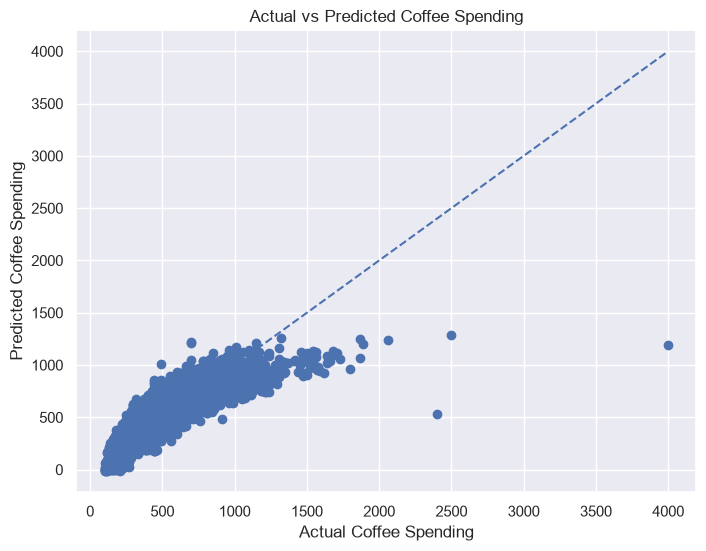


Actual vs Predicted:
   Actual Spending  Predicted Spending
0              380          434.617640
1              920          737.266316
2              470          711.483108
3              620          464.558196
4              530          416.702470
5              300          419.051768
6              910          955.381330
7              530          548.650240
8              570          772.629381
9              970          710.304277


In [118]:
X = df.drop(columns=["Coffee_Spend"])
y = df["Coffee_Spend"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

#identify column type
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

print("\nCategorical Features:")
print(list(categorical_features))

print("\nNumerical Features:")
print(list(numerical_features))


# categorial Pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# numerical Pipeline

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

#preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numerical", numerical_pipeline, numerical_features)
    ]
)


# 6. CREATE REGRESSION PIPELINE


model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

# model evaluation
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
# Lower MAE is better

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)
# Lower RMSE is better


r2= r2_score(y_test, y_pred)
print("R2 Score:", r2)
# R2 tell us how well the model explains the variation in coffee spending.
# higher R2 is better

#  adding actual vs pridicted coffee spending graph
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")

plt.xlabel("Actual Coffee Spending")
plt.ylabel("Predicted Coffee Spending")
plt.title("Actual vs Predicted Coffee Spending")

plt.show()

#compare actual vs pridiction
results = pd.DataFrame({
    "Actual Spending": y_test.values,
    "Predicted Spending": y_pred
})

print("\nActual vs Predicted:")
print(results.head(10))


# *Coffee Market / Demand Trend Forecasting*

In [119]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


FILE_PATH = "indian-coffee-all-responses (1).csv"

df = pd.read_csv(FILE_PATH)

print("Dataset Loaded Successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst 5 Rows:")
print(df.head())

Dataset Loaded Successfully!
Rows: 11072
Columns: 21

First 5 Rows:
  respondentId  source   age gender        city occupation  monthlyIncome  \
0          NaN  public  22.0    Man       Delhi    Student  Below ₹25,000   
1          NaN  public  22.0    Man       Delhi    Student  Below ₹25,000   
2          NaN  public  20.0    Man       Delhi    Student  Below ₹25,000   
3          NaN  public  21.0    Man       Delhi    Student  Below ₹25,000   
4          NaN  public  20.0  Woman  New delhi     Student            NaN   

  coffeeFrequency      preferredCoffeeType preferredBrand  ...  \
0           daily                  Instant       Davidoff  ...   
1           daily  Espresso / black coffee            Bru  ...   
2           daily  Espresso / black coffee        Nescafe  ...   
3           daily  Espresso / black coffee        Nescafe  ...   
4           daily                Cold brew       Nescafe   ...   

  purchaseLocation    purchaseMode    priceSensitivity tastePreference  

In [120]:

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.columns = df.columns.str.strip()

print("\nColumn Names:")
print(df.columns.tolist())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 11072 entries, 0 to 11071
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   respondentId         11000 non-null  str    
 1   source               11072 non-null  str    
 2   age                  11066 non-null  float64
 3   gender               11070 non-null  str    
 4   city                 11069 non-null  str    
 5   occupation           11069 non-null  str    
 6   monthlyIncome        11034 non-null  str    
 7   coffeeFrequency      11072 non-null  str    
 8   preferredCoffeeType  11062 non-null  str    
 9   preferredBrand       11059 non-null  str    
 10  monthlyCoffeeSpend   11059 non-null  str    
 11  purchaseLocation     11056 non-null  str    
 12  purchaseMode         11062 non-null  str    
 13  priceSensitivity     11054 non-null  str    
 14  tastePreference      11060 non-null  str    
 15  brandLoyalty         1105


Demand Score Created!
count    11072.000000
mean         2.116875
std          0.663180
min          0.735714
25%          1.553571
50%          2.092857
75%          2.682143
max          3.800000
Name: Demand_Score, dtype: float64


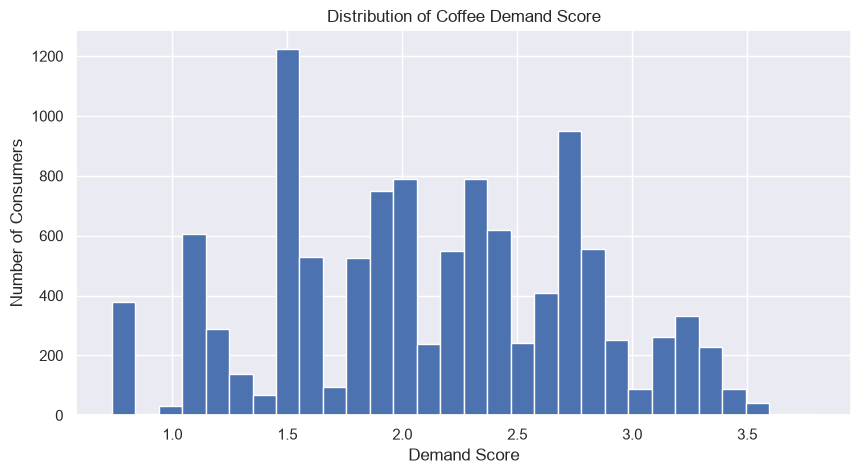

In [121]:

# Coffee consumption frequency score
frequency_mapping = {
    "Rarely": 1,
    "1-2 times/week": 2,
    "3-4 times/week": 3,
    "Daily": 4,
    "Multiple times/day": 5
}

df["Coffee_Frequency_Score"] = (
    df["coffeeFrequency"]
    .map(frequency_mapping))


# Purchase intention score

intention_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3}

df["Purchase_Intention_Score"] = (
    df["purchaseIntention"]
    .map(intention_mapping))

# Price sensitivity score

pH_mapping = {
    "Somewhat sensitive": 1,
    "Neutral": 2,
    "Not sensitive at all": 3}

df["Price_Sensitivity_Score"] = (
    df["priceSensitivity"]
    .map(pH_mapping))

# Brand loyalty score

loyalty_mapping = {
    "Very loyal": 3,
    "Somewhat loyal": 2,
    "I like to explore": 1}

df["Brand_Loyalty_Score"] = (
    df["brandLoyalty"]
    .map(loyalty_mapping))


numeric_columns = [
    "age",
    "monthlyIncome",
    "monthlyCoffeeSpend",
    "Coffee_Frequency_Score",
    "Purchase_Intention_Score",
    "Price_Sensitivity_Score",
    "Brand_Loyalty_Score"]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())


# Demand Score combines:
#
# Coffee consumption frequency
# Purchase intention
# Monthly coffee spending
#
# This is a survey-based demand indicator,
# NOT actual market sales.

df["Demand_Score"] = (
    0.40 * df["Coffee_Frequency_Score"]
    + 0.30 * df["Purchase_Intention_Score"]
    + 0.30 * (
        df["monthlyCoffeeSpend"]
        / df["monthlyCoffeeSpend"].max()
        * 3
    )
)

print("\nDemand Score Created!")

print(df["Demand_Score"].describe())

plt.figure(figsize=(10, 5))

plt.hist(
    df["Demand_Score"],
    bins=30
)

plt.title("Distribution of Coffee Demand Score")
plt.xlabel("Demand Score")
plt.ylabel("Number of Consumers")

plt.show()


TIME SERIES DATA CHECK
Date columns found: ['monthlyIncome', 'monthlyCoffeeSpend']

Demand by Period:
    Period    Demand
0        1  2.079020
1        2  2.079168
2        3  2.123303
3        4  2.063366
4        5  2.123024
5        6  2.118105
6        7  2.143220
7        8  2.136481
8        9  2.089743
9       10  2.108351
10      11  2.168437
11      12  2.121855
12      13  2.134893
13      14  2.112446
14      15  2.131717
15      16  2.141168
16      17  2.102092
17      18  2.101283
18      19  2.092113
19      20  2.144879
20      21  2.101492
21      22  2.129245
22      23  2.133584
23      24  2.126098


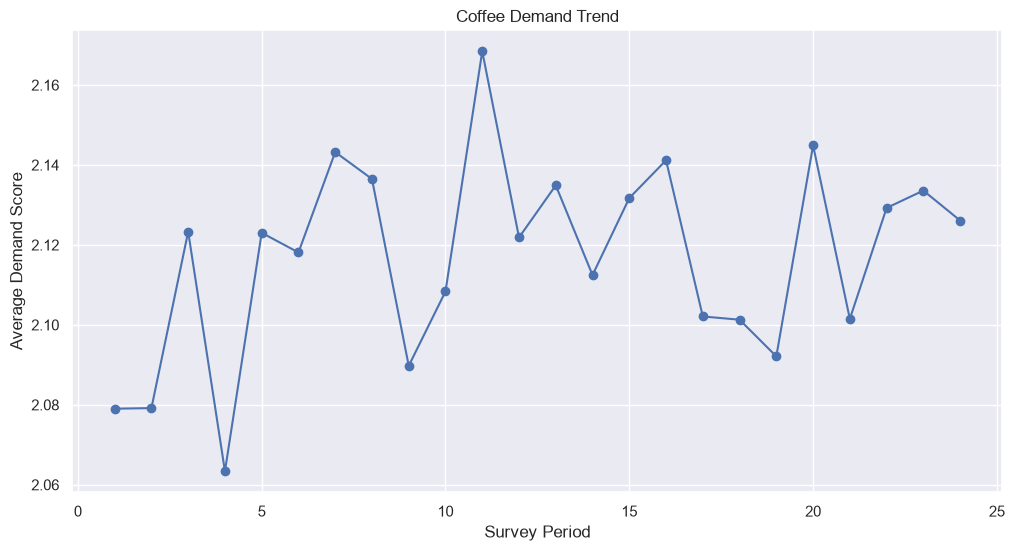


Moving Average:
    Period    Demand  Moving_Average
0        1  2.079020             NaN
1        2  2.079168             NaN
2        3  2.123303        2.093830
3        4  2.063366        2.088612
4        5  2.123024        2.103231
5        6  2.118105        2.101498
6        7  2.143220        2.128117
7        8  2.136481        2.132602
8        9  2.089743        2.123148
9       10  2.108351        2.111525
10      11  2.168437        2.122177
11      12  2.121855        2.132881
12      13  2.134893        2.141728
13      14  2.112446        2.123065
14      15  2.131717        2.126352
15      16  2.141168        2.128444
16      17  2.102092        2.124992
17      18  2.101283        2.114848
18      19  2.092113        2.098496
19      20  2.144879        2.112759
20      21  2.101492        2.112828
21      22  2.129245        2.125206
22      23  2.133584        2.121440
23      24  2.126098        2.129642


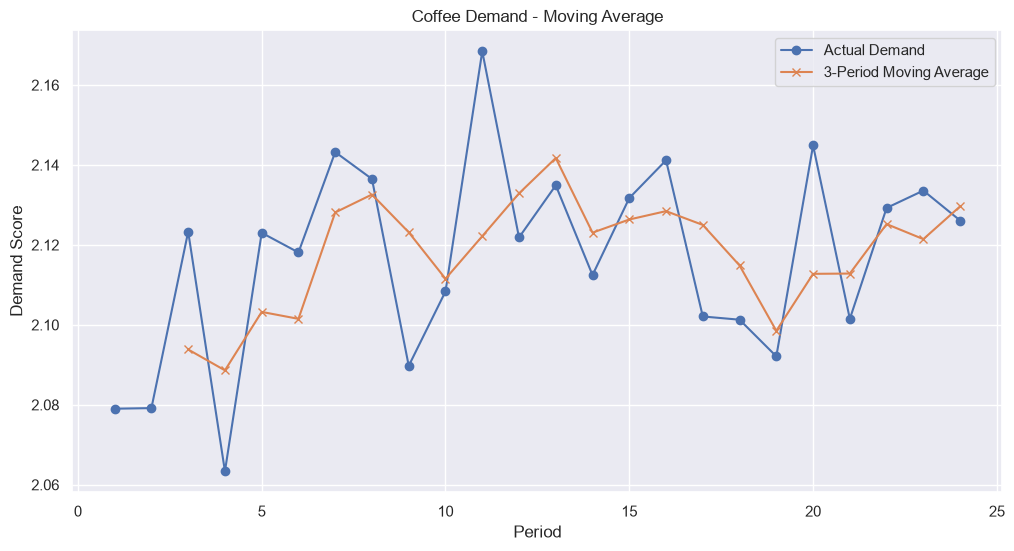

In [122]:

print("\n" + "=" * 60)
print("TIME SERIES DATA CHECK")
print("=" * 60)

date_columns = []

for col in df.columns:

    col_lower = col.lower()

    if (
        "date" in col_lower
        or "month" in col_lower
        or "year" in col_lower
        or "time" in col_lower
    ):
        date_columns.append(col)


if len(date_columns) == 0:

    print("""
No date/month/year/time column was found.

Therefore this survey dataset cannot support a genuine
historical time-series forecast such as:

January -> February -> March -> April

without adding actual time-indexed data.

The following model uses an ordered survey-demand series
constructed from the available responses.

This is a DEMONSTRATION of demand forecasting,
not a forecast of actual monthly Indian coffee sales.
""")

else:

    print("Date columns found:", date_columns)

if "Respondent ID" in df.columns:

    df = df.sort_values("Respondent ID").reset_index(drop=True)

else:

    df = df.reset_index(drop=True)


# Create 24 sequential periods

NUMBER_OF_PERIODS = 24

df["Period"] = pd.qcut(
    np.arange(len(df)),
    q=NUMBER_OF_PERIODS,
    labels=False
) + 1

# Calculate average demand for every period

demand_by_period = (
    df.groupby("Period")["Demand_Score"]
    .mean()
    .reset_index()
)

demand_by_period.columns = [
    "Period",
    "Demand"
]

print("\nDemand by Period:")
print(demand_by_period)

plt.figure(figsize=(12, 6))

plt.plot(
    demand_by_period["Period"],
    demand_by_period["Demand"],
    marker="o"
)

plt.title("Coffee Demand Trend")
plt.xlabel("Survey Period")
plt.ylabel("Average Demand Score")

plt.grid(True)

plt.show()

WINDOW = 3

demand_by_period["Moving_Average"] = (
    demand_by_period["Demand"]
    .rolling(window=WINDOW)
    .mean()
)

print("\nMoving Average:")
print(demand_by_period)

plt.figure(figsize=(12, 6))

plt.plot(
    demand_by_period["Period"],
    demand_by_period["Demand"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    demand_by_period["Period"],
    demand_by_period["Moving_Average"],
    marker="x",
    label="3-Period Moving Average"
)

plt.title("Coffee Demand - Moving Average")
plt.xlabel("Period")
plt.ylabel("Demand Score")

plt.legend()
plt.grid(True)

plt.show()

In [123]:

X = demand_by_period[["Period"]]
y = demand_by_period["Demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train)
linear_prediction = linear_model.predict(X_test)

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42)

random_forest_model.fit(
    X_train,
    y_train)

random_forest_prediction = (
    random_forest_model.predict(X_test))

gradient_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=42)

gradient_model.fit(
    X_train,
    y_train)

gradient_prediction = (
    gradient_model.predict(X_test))

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    print("\n" + "-" * 50)

    print(name)

    print("-" * 50)

    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }



# *EVALUATE ALL MODELS*

In [124]:

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_prediction
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_prediction
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_prediction
    )
)



--------------------------------------------------
Linear Regression
--------------------------------------------------
MAE : 0.0242
RMSE: 0.0272
R2  : -2.5554

--------------------------------------------------
Random Forest
--------------------------------------------------
MAE : 0.0267
RMSE: 0.029
R2  : -3.0254

--------------------------------------------------
Gradient Boosting
--------------------------------------------------
MAE : 0.0271
RMSE: 0.0312
R2  : -3.6639



MODEL COMPARISON
               Model       MAE      RMSE        R2
0  Linear Regression  0.024208  0.027240 -2.555373
1      Random Forest  0.026703  0.028985 -3.025425
2  Gradient Boosting  0.027106  0.031199 -3.663876

Best Model based on R2:
Linear Regression


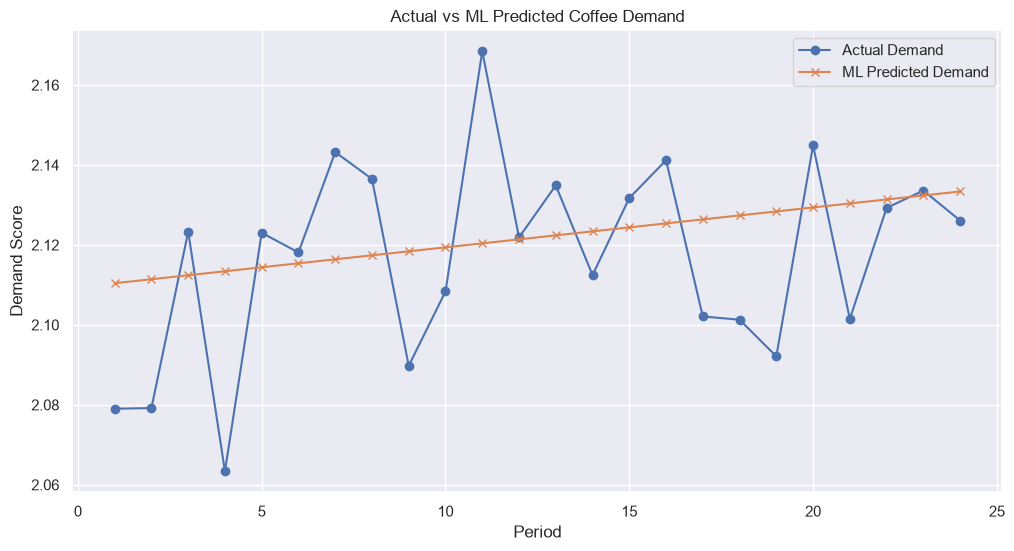

In [125]:

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
print("=" * 60)

print(results_df)

# Higher R2 = better

best_model_name = (
    results_df
    .sort_values("R2", ascending=False)
    .iloc[0]["Model"]
)

print("\nBest Model based on R2:")
print(best_model_name)

all_periods = demand_by_period[["Period"]]

if best_model_name == "Linear Regression":

    historical_prediction = (
        linear_model.predict(all_periods)
    )

elif best_model_name == "Random Forest":

    historical_prediction = (
        random_forest_model.predict(all_periods)
    )

else:

    historical_prediction = (
        gradient_model.predict(all_periods)
    )

plt.figure(figsize=(12, 6))

plt.plot(
    demand_by_period["Period"],
    demand_by_period["Demand"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    demand_by_period["Period"],
    historical_prediction,
    marker="x",
    label="ML Predicted Demand"
)

plt.title("Actual vs ML Predicted Coffee Demand")

plt.xlabel("Period")

plt.ylabel("Demand Score")

plt.legend()

plt.grid(True)

plt.show()

FUTURE_PERIODS = 6

last_period = demand_by_period["Period"].max()

future_period_numbers = np.arange(
    last_period + 1,
    last_period + FUTURE_PERIODS + 1
)

future_X = pd.DataFrame({
    "Period": future_period_numbers
})


# Select best model

if best_model_name == "Linear Regression":

    future_prediction = (
        linear_model.predict(future_X)
    )

elif best_model_name == "Random Forest":

    future_prediction = (
        random_forest_model.predict(future_X)
    )

else:

    future_prediction = (
        gradient_model.predict(future_X)
    )





FUTURE COFFEE DEMAND FORECAST
   Future_Period  Forecasted_Demand
0             25           2.134358
1             26           2.135356
2             27           2.136354
3             28           2.137352
4             29           2.138350
5             30           2.139349


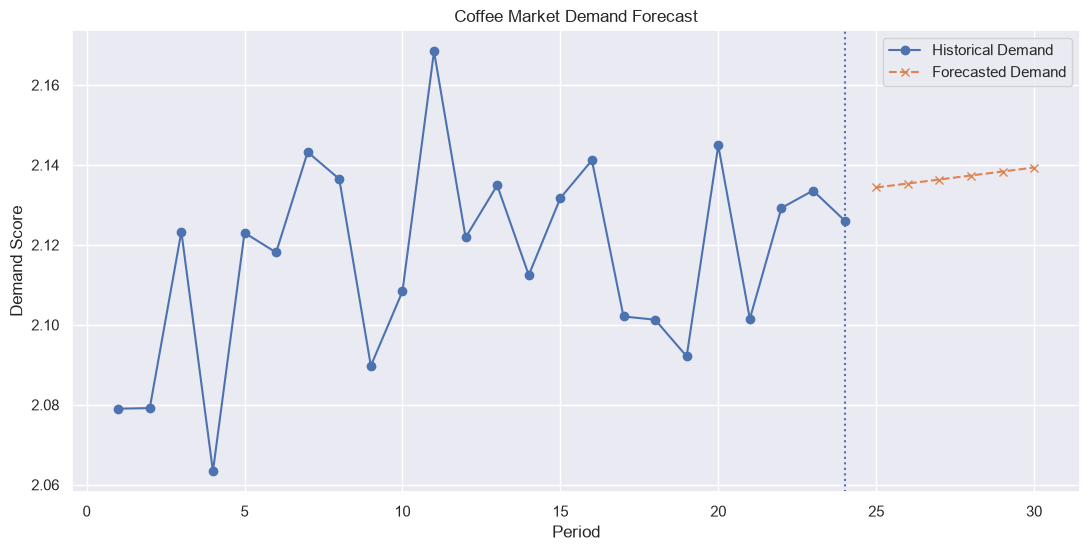


DEMAND TREND ANALYSIS
Starting Demand: 2.079
Latest Demand: 2.126
Change: 0.047
Percentage Change: 2.26 %

FUTURE DEMAND TREND
First Forecast: 2.134
Last Forecast: 2.139
Forecast Change: 0.005
Forecast Percentage Change: 0.23 %

Files saved successfully!
1. coffee_demand_by_period.csv
2. coffee_demand_forecast.csv
3. coffee_demand_model_comparison.csv


COFFEE MARKET / DEMAND FORECASTING PROJECT COMPLETED

Dataset:
Indian Coffee Consumer Survey

Number of Respondents:
4352

Demand indicator:
Coffee Frequency + Purchase Intention + Monthly Coffee Spend

Algorithms:
1. Moving Average
2. Linear Regression
3. Random Forest Regression
4. Gradient Boosting Regression

Evaluation Metrics:
1. MAE
2. RMSE
3. R2 Score

Outputs:
1. Demand trend
2. Model comparison
3. Historical demand prediction
4. Future demand forecast
5. CSV result files

Important Limitation:
The survey dataset does not contain actual dates/months.
Therefore the forecast is a survey-based demonstration and
should not be inte

In [126]:
forecast_df = pd.DataFrame({

    "Future_Period":
        future_period_numbers,

    "Forecasted_Demand":
        future_prediction

})


print("\nFUTURE COFFEE DEMAND FORECAST")
print("=" * 60)

print(forecast_df)
plt.figure(figsize=(13, 6))

plt.plot(
    demand_by_period["Period"],
    demand_by_period["Demand"],
    marker="o",
    label="Historical Demand"
)

plt.plot(
    future_period_numbers,
    future_prediction,
    marker="x",
    linestyle="--",
    label="Forecasted Demand"
)

plt.axvline(
    last_period,
    linestyle=":"
)

plt.title(
    "Coffee Market Demand Forecast"
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "Demand Score"
)

plt.legend()

plt.grid(True)

plt.show()

first_demand = demand_by_period.iloc[0]["Demand"]

last_demand = demand_by_period.iloc[-1]["Demand"]

change = last_demand - first_demand

percentage_change = (
    change / first_demand
) * 100


print("\nDEMAND TREND ANALYSIS")
print("=" * 60)

print(
    "Starting Demand:",
    round(first_demand, 3)
)

print(
    "Latest Demand:",
    round(last_demand, 3)
)

print(
    "Change:",
    round(change, 3)
)

print(
    "Percentage Change:",
    round(percentage_change, 2),
    "%"
)

first_forecast = forecast_df.iloc[0]["Forecasted_Demand"]

last_forecast = forecast_df.iloc[-1]["Forecasted_Demand"]

future_change = last_forecast - first_forecast

future_percentage_change = (
    future_change / first_forecast
) * 100


print("\nFUTURE DEMAND TREND")
print("=" * 60)

print(
    "First Forecast:",
    round(first_forecast, 3)
)

print(
    "Last Forecast:",
    round(last_forecast, 3)
)

print(
    "Forecast Change:",
    round(future_change, 3)
)

print(
    "Forecast Percentage Change:",
    round(future_percentage_change, 2),
    "%"
)

demand_by_period.to_csv(
    "coffee_demand_by_period.csv",
    index=False
)

forecast_df.to_csv(
    "coffee_demand_forecast.csv",
    index=False
)

results_df.to_csv(
    "coffee_demand_model_comparison.csv",
    index=False
)


print("\nFiles saved successfully!")

print("1. coffee_demand_by_period.csv")
print("2. coffee_demand_forecast.csv")
print("3. coffee_demand_model_comparison.csv")

print("\n")
print("=" * 70)
print("COFFEE MARKET / DEMAND FORECASTING PROJECT COMPLETED")
print("=" * 70)

print("""
Dataset:
Indian Coffee Consumer Survey

Number of Respondents:
4352

Demand indicator:
Coffee Frequency + Purchase Intention + Monthly Coffee Spend

Algorithms:
1. Moving Average
2. Linear Regression
3. Random Forest Regression
4. Gradient Boosting Regression

Evaluation Metrics:
1. MAE
2. RMSE
3. R2 Score

Outputs:
1. Demand trend
2. Model comparison
3. Historical demand prediction
4. Future demand forecast
5. CSV result files

Important Limitation:
The survey dataset does not contain actual dates/months.
Therefore the forecast is a survey-based demonstration and
should not be interpreted as an actual monthly market-sales
forecast.
""")

In [127]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/indian-coffee-all-responses final dataset.csv')
df

,age,gender,city,occupation,monthlyIncome,coffeeFrequency,preferredCoffeeType,preferredBrand,monthlyCoffeeSpend,purchaseLocation,purchaseMode,priceSensitivity,tastePreference,brandLoyalty,willingnessToTry,preferredPriceRange,purchaseIntention
0,22.0,Male,Delhi,Student,12500.000000,Daily,Instant Coffee,Davidoff,700.0,App,Both equally,Somewhat Sensitive,Strong,Very Loyal,Very Willing,950.000000,Probably Would Buy
1,22.0,Male,Delhi,Student,12500.000000,Daily,Espresso / black coffee,Bru,700.0,Grocery store,Both equally,Somewhat Sensitive,Strong,Very Loyal,Only With A Recommendation,950.000000,Not Sure
2,20.0,Male,Delhi,Student,12500.000000,Daily,Espresso / black coffee,Nescafé,700.0,Instamart,Online,Neutral,Strong,I Like To Explore,Somewhat Willing,400.000000,Probably Would Buy
3,21.0,Male,Delhi,Student,12500.000000,Daily,Espresso / black coffee,Nescafé,700.0,Amazon App,Online,Neutral,Strong,Very Loyal,Only With A Recommendation,950.000000,Probably Would Buy
4,20.0,Female,New delhi,Student,48826.835237,Daily,Cold brew,Nescafé,700.0,Supermarket,Offline,Neutral,Strong,Very Loyal,Likely,270.142883,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11067,26.0,Male,Surat,Government Employee,54700.000000,1-2 times/week,Americano,Nescafé,380.0,Brand Website,Online,High,Balanced,Low,Neutral,130.000000,Medium
11068,31.0,Male,Ahmedabad,Private Sector Employee,28300.000000,1-2 times/week,Filter Coffee,Tata Coffee,240.0,Office/Canteen,Offline,Low,Bitter,Medium,Likely,700.000000,Medium
11069,30.0,Female,Jaipur,Other,25700.000000,Multiple times/day,Espresso,Third Wave Coffee,1210.0,Supermarket/Grocery Store,Offline,Medium,Balanced,Medium,Unlikely,700.000000,High
11070,37.0,Male,Indore,Government Employee,42600.000000,Daily,Instant Coffee,Country Bean,550.0,Café,Offline,High,Strong,Medium,Very Likely,130.000000,High


In [128]:
df.drop(columns=['tastePreference', 'occupation', 'gender'], inplace = True)

In [129]:
df['young_age']=(df['age']<=30)
df.info()
df.value_counts('young_age')

<class 'pandas.DataFrame'>
RangeIndex: 11072 entries, 0 to 11071
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  11072 non-null  float64
 1   city                 11072 non-null  str    
 2   monthlyIncome        11072 non-null  float64
 3   coffeeFrequency      11072 non-null  str    
 4   preferredCoffeeType  11072 non-null  str    
 5   preferredBrand       11072 non-null  str    
 6   monthlyCoffeeSpend   11072 non-null  float64
 7   purchaseLocation     11072 non-null  str    
 8   purchaseMode         11072 non-null  str    
 9   priceSensitivity     11072 non-null  str    
 10  brandLoyalty         11072 non-null  str    
 11  willingnessToTry     11072 non-null  str    
 12  preferredPriceRange  11072 non-null  float64
 13  purchaseIntention    11072 non-null  str    
 14  young_age            11072 non-null  bool   
dtypes: bool(1), float64(4), str(10)
memory usage: 1

young_age
True     5692
False    5380
Name: count, dtype: int64

In [130]:
df.value_counts('coffeeFrequency')
df['coffeeFrequency']=df['coffeeFrequency'].map({
  '3-4 times/week':0,
  'Daily':1,
  '1-2 times/week':2,
   'Rarely':3,
  'Multiple times/day':4,
  'sometimes':5,
  'few':6
})

df.value_counts("brandLoyalty")
df["brandLoyalty"]=df["brandLoyalty"].map({
    'Medium':1,
    'High':2,
    'Low':0,
    "I Like To Explore":1,
    'Very Loyal':2,
    'Somewhat Loyal':1,
    'No Preference':0

})

df['purchaseIntention']=df['purchaseIntention'].map({
    'Medium':1,
    'High':2,
    'Low':0,
    'Probably Would Buy':1,
    'Not Sure':0,
    'Definitely Would Buy':2,
    'Probably Would Not Buy':1
})
df.value_counts("purchaseIntention")

df.value_counts('purchaseMode')
df['purchaseMode']=df['purchaseMode'].map({
    'Offline':0,
    'Both':1,
    'Online':2,
    'Both equally':1
})

df.value_counts('willingnessToTry')
df['willingnessToTry']=df['willingnessToTry'].map({
    'Likely':2,
    'Neutral':1,
    'Very Likely':2,
    'Unlikely':0,
    'Very Unlikely':0,
    'Somewhat Willing':1,
    'Very Willing':2,
    'Not Currently Interested':0
})

In [131]:
df.value_counts('priceSensitivity')
df['priceSensitivity']=df['priceSensitivity'].map({
    'High':2,
    'Low':0,
    'Medium':1,
    'Neutral':3,
    'Somewhat Sensitive':4,
    'Very Sensitive':5,
    'Not Very Sensitive':6
})

city_features = df.groupby('city')[[ 'monthlyCoffeeSpend','priceSensitivity',]].mean().reset_index()

In [132]:
brand_map = {
    'Nescafe': 'Mass/Instant',
    'Bru': 'Mass/Instant',
    'Davidoff': 'Mass/Instant',
    'Blue Tokai': 'Premium',
    'Sleepy Owl': 'Premium',
    'Third Wave Coffee': 'Premium',
    'Rage Coffee': 'Premium',
    'Starbucks': 'Café Chain',
    'Café Coffee Day': 'Café Chain',
    'Tim Hortons': 'Café Chain',
    'Country Bean': 'Café Chain',
    'Local / Regional Brand': 'Local/Regional',
    'Tata Coffee': 'Local/Regional',
    'Other': 'Other'
}

df['preferred_brand_grouped'] = df['preferredBrand'].str.strip().replace(brand_map)

In [133]:
df['Premium_brand'] = df['preferred_brand_grouped'].isin(['Premium','Café Chain']).astype(int)
df['bought_online'] = df['purchaseLocation'].isin(['Online Marketplace']).astype(int)
df['Premium_type']=df['preferredCoffeeType'].isin(['Flavoured / Specialty','Cold Brew']).astype(int)
new_features=df.groupby('city')[['Premium_brand','bought_online','Premium_type']].mean().reset_index()
city_features=pd.merge(city_features,new_features,on='city')


In [134]:
external_city_data=pd.read_csv('data/external_city_data.csv')
external_city_data

,city,city_tier,cafe_density,income_index,competitor_count,ecommerce_pct
0,Delhi,1,74.981605,108275.000724,33.299849,76.973170
1,Mumbai,1,66.240746,80459.808212,16.452090,82.323523
2,Bengaluru,1,84.044600,99782.540223,15.514612,84.398197
3,Chennai,1,93.297706,82431.868874,19.545624,68.668090
4,Kolkata,1,72.169690,93366.475107,25.798625,70.824583
5,Hyderabad,1,84.474116,79882.285123,22.303616,72.327237
6,Pune,1,78.242799,102481.158649,19.991845,75.284689
7,Ahmedabad,1,83.696583,76625.764445,30.188621,68.410482
8,Jaipur,2,21.951548,68722.138431,11.690688,56.167947
9,Lucknow,2,29.138413,47441.802850,9.158097,48.803050


In [135]:
city_features=city_features.merge(external_city_data, on='city', how='inner')
city_features

,city,monthlyCoffeeSpend,priceSensitivity,Premium_brand,bought_online,Premium_type,city_tier,cafe_density,income_index,competitor_count,ecommerce_pct
0,Ahmedabad,580.584416,1.110390,0.371753,0.144481,0.0,1,83.696583,76625.764445,30.188621,68.410482
1,Bengaluru,560.656219,1.082272,0.373164,0.155730,0.0,1,84.044600,99782.540223,15.514612,84.398197
2,Bhopal,555.819398,1.150502,0.384615,0.140468,0.0,2,28.428035,58567.402079,4.268318,56.043940
3,Bhubaneswar,533.345455,1.149091,0.374545,0.214545,0.0,2,20.165664,65386.535711,9.361716,54.580143
4,Chandigarh,547.751323,1.034392,0.391534,0.137566,0.0,2,22.654775,49899.571560,3.407046,46.506607
5,Chennai,573.660436,1.074766,0.362928,0.183801,0.0,1,93.297706,82431.868874,19.545624,68.668090
6,Coimbatore,556.758105,1.144638,0.376559,0.137157,0.0,2,48.184968,67370.683761,8.381100,58.437485
7,Delhi,599.541439,1.186753,0.380865,0.139834,0.0,1,74.981605,108275.000724,33.299849,76.973170
8,Hyderabad,585.594771,1.113725,0.385621,0.154248,0.0,1,84.474116,79882.285123,22.303616,72.327237
9,Indore,531.924051,1.048101,0.443038,0.151899,0.0,2,27.763399,61563.057109,5.805400,50.401360


In [136]:
#K-Means clustering for city wise features
import sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

#Defining and scaling the dataset
X = city_features.drop(columns=['city'])
X_scaled = StandardScaler().fit_transform(X)

#Training model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
city_features['cluster'] = kmeans.fit_predict(X_scaled)

city_features.groupby('cluster').mean(numeric_only=True)



,monthlyCoffeeSpend,priceSensitivity,Premium_brand,bought_online,Premium_type,city_tier,cafe_density,income_index,competitor_count,ecommerce_pct
cluster,,,,,,,,,,
0,573.109670,1.09477,0.371503,0.150646,0.0,1.0,79.643481,90413.112670,22.88686,74.901246
1,490.000000,3.50000,0.000000,0.000000,0.0,3.0,21.045000,34044.990000,2.04500,30.225000
2,556.260021,1.10472,0.395098,0.158757,0.0,2.0,29.615351,57854.915929,7.81193,51.504696


In [137]:
label_map = {0: 'Premium coffee markets', 1: 'Emerging coffee markets', 2: 'Mass/instant-oriented markets'}
city_features['market_type'] = city_features['cluster'].map(label_map)

In [138]:
#Evaluation
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled, city_features['cluster']))

0.6287524492286836


In [139]:
X_no_tier = city_features.drop(columns=['city', 'city_tier', 'cluster', 'market_type'])
X_no_tier_scaled = StandardScaler().fit_transform(X_no_tier)
km2 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_no_tier_scaled)
print(silhouette_score(X_no_tier_scaled, km2.labels_))

0.5946849551794823


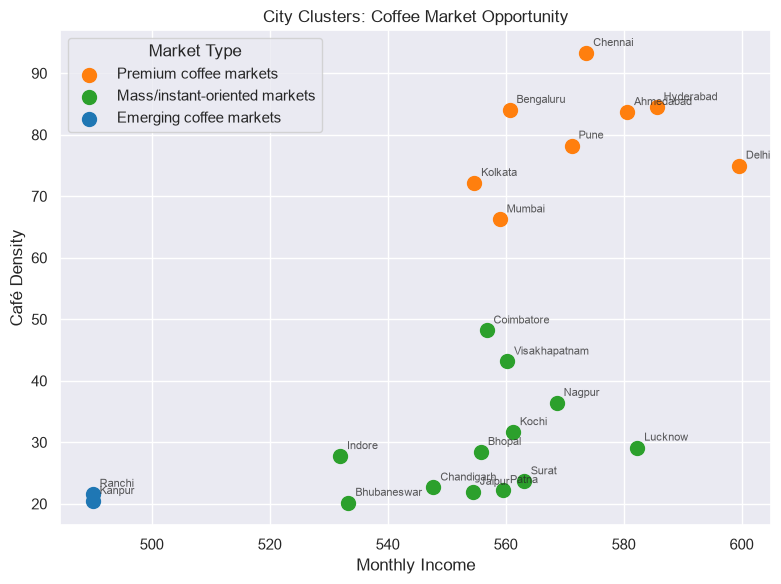

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
colors = {0: 'tab:orange', 1: 'tab:blue', 2: 'tab:green'}

for cluster in city_features['cluster'].unique():
    mask = city_features['cluster'] == cluster
    plt.scatter(
        city_features.loc[mask, 'monthlyCoffeeSpend'],
        city_features.loc[mask, 'cafe_density'],
        label=city_features.loc[mask, 'market_type'].iloc[0],
        color=colors[cluster],
        s=100
    )

# label each point with the city name
for i, row in city_features.iterrows():
    plt.annotate(row['city'], (row['monthlyCoffeeSpend'], row['cafe_density']), fontsize=8, alpha=0.75, xytext=(5,5), textcoords='offset points')

plt.xlabel('Monthly Income')
plt.ylabel('Café Density')
plt.title('City Clusters: Coffee Market Opportunity')
plt.legend(title='Market Type')
plt.tight_layout()
plt.grid(True)
plt.show()

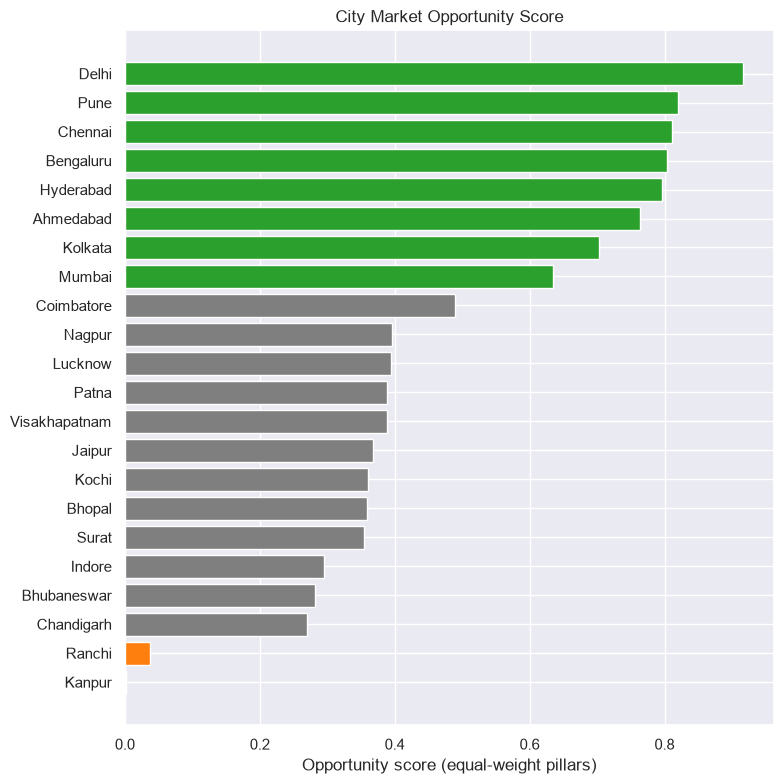

In [141]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate a normalized opportunity score using available numeric fields
# We standardise the indicators to a 0-1 scale so they can be combined equally
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# Creating an 'opportunity_score' based on key indicators
city_features['opportunity_score'] = (
    min_max_scale(city_features['monthlyCoffeeSpend']) +
    min_max_scale(city_features['cafe_density']) +
    min_max_scale(city_features['income_index'])
) / 3

# Map correctly to the variable city_features instead of city
c = city_features.sort_values("opportunity_score")

# Define colors matching the actual cluster label strings inside city_features
colors = c["market_type"].map({
    "Premium coffee markets": "tab:green",
    "Emerging coffee markets": "tab:orange",
    "Mass/instant-oriented markets": "tab:gray"
})

# Plot the horizontal bar chart
plt.figure(figsize=(8, 8))
plt.barh(c["city"], c["opportunity_score"], color=colors)
plt.xlabel("Opportunity score (equal-weight pillars)")
plt.title("City Market Opportunity Score")
plt.tight_layout()
plt.show()

# Ensure output directory exists and write CSV
os.makedirs("data/modules", exist_ok=True)
city_features.round(3).to_csv("data/modules/city_scores.csv", index=False)

# Added part — Market Entry Recommendation

The cells below are additions to the original notebook. The earlier code is left as it was.

This section connects the existing consumer/city work into one transparent market-entry score and saves the outputs separately.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('.')
OUT = BASE / 'outputs'
(OUT / 'datasets').mkdir(parents=True, exist_ok=True)
(OUT / 'diagrams').mkdir(parents=True, exist_ok=True)

final_data = pd.read_csv('data/indian-coffee-all-responses final dataset.csv')
city_ext = pd.read_csv('data/external_city_data.csv')
print('Added section data shape:', final_data.shape)

In [ ]:
# Consumer cluster profiles using the same three variables used above
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

seg = final_data.copy()
X_seg = seg[['monthlyIncome','monthlyCoffeeSpend','preferredPriceRange']].fillna(seg[['monthlyIncome','monthlyCoffeeSpend','preferredPriceRange']].median())
X_seg = StandardScaler().fit_transform(X_seg)
seg['cluster'] = KMeans(n_clusters=3, random_state=0, n_init=10).fit_predict(X_seg)

cluster_profiles = seg.groupby('cluster')[['age','monthlyIncome','monthlyCoffeeSpend','preferredPriceRange']].agg(['mean','median','count']).round(2)
cluster_profiles.to_csv(OUT/'datasets/consumer_cluster_profiles.csv')
seg[['city','age','monthlyIncome','monthlyCoffeeSpend','preferredPriceRange','cluster']].to_csv(OUT/'datasets/consumer_cluster_assignments.csv', index=False)
cluster_profiles

In [ ]:
# City-level market entry score
d = final_data.copy()
freq_map = {'Rarely':1,'few':1,'1-2 times/week':2,'sometimes':2,'3-4 times/week':3,'Daily':4,'daily':4,'Multiple times/day':5}
d['coffee_freq_score'] = d['coffeeFrequency'].map(freq_map)
try_map = {'Likely':1,'Very Likely':1,'Unlikely':0,'Very Unlikely':0,'Somewhat willing':1,'Very willing':1,'Not currently interested':0,'Only with a recommendation':0,'Neutral':0,'Very Willing':1,'Only With A Recommendation':0}
d['adoption_signal'] = d['willingnessToTry'].map(try_map)
d['purchase_intention_signal'] = d['purchaseIntention'].map({'High':1,'Definitely would buy':1,'Low':0,'Not sure':0,'Probably would buy':1,'Medium':0.5,'Probably Would Buy':1,'Not Sure':0,'Definitely Would Buy':1,'Probably Would Not Buy':0.5})
brand_groups = {'Nescafe':'Mass/Instant','Nescafé':'Mass/Instant','Bru':'Mass/Instant','Davidoff':'Mass/Instant','Blue Tokai':'Premium','Sleepy Owl':'Premium','Third Wave Coffee':'Premium','Rage Coffee':'Premium','Starbucks':'Café Chain','Café Coffee Day':'Café Chain','Tim Hortons':'Café Chain','Country Bean':'Café Chain'}
d['brand_group'] = d['preferredBrand'].astype(str).str.strip().replace(brand_groups)
d['premium_brand'] = d['brand_group'].isin(['Premium','Café Chain']).astype(int)
d['bought_online'] = d['purchaseLocation'].astype(str).str.lower().isin(['online marketplace','app','online']).astype(int)
d['premium_type'] = d['preferredCoffeeType'].astype(str).isin(['Flavoured / Specialty','Cold Brew']).astype(int)

city = d.groupby('city').agg(monthlyCoffeeSpend=('monthlyCoffeeSpend','mean'), income=('monthlyIncome','mean'), adoption_signal=('adoption_signal','mean'), purchase_intention=('purchase_intention_signal','mean'), premium_brand_share=('premium_brand','mean'), online_share=('bought_online','mean'), premium_type_share=('premium_type','mean')).reset_index()
city = city.merge(city_ext, on='city', how='inner')

def mm(s):
    s = pd.Series(s, dtype=float)
    if s.max() == s.min(): return pd.Series(np.ones(len(s))*0.5, index=s.index)
    return (s-s.min())/(s.max()-s.min())

city['adoption_score'] = mm(city['adoption_signal'].fillna(city['adoption_signal'].mean()))
city['spending_score'] = mm(city['monthlyCoffeeSpend'])
city['city_strength_score'] = (mm(city['cafe_density']) + mm(city['income_index']) + mm(city['ecommerce_pct'])) / 3
city['trend_score'] = 0.5
city['market_entry_score'] = (city['adoption_score'] + city['spending_score'] + city['city_strength_score'] + city['trend_score']) / 4
city = city.sort_values('market_entry_score', ascending=False).reset_index(drop=True)
city['rank'] = np.arange(1, len(city)+1)
city.to_csv(OUT/'datasets/market_entry_ranking.csv', index=False)
city.head(10)

In [ ]:
# Sensitivity check for the score weights
scenarios = {'Equal':(.25,.25,.25,.25), 'Adoption focus':(.40,.20,.20,.20), 'Spending focus':(.20,.40,.20,.20), 'City focus':(.20,.20,.40,.20), 'Trend focus':(.20,.20,.20,.40)}
sensitivity = []
for name,(wa,ws,wc,wt) in scenarios.items():
    score = wa*city.adoption_score + ws*city.spending_score + wc*city.city_strength_score + wt*city.trend_score
    tmp = city[['city']].copy(); tmp['score'] = score
    tmp = tmp.sort_values('score', ascending=False).head(10).reset_index(drop=True)
    tmp['rank'] = np.arange(1,len(tmp)+1); tmp['scenario'] = name
    sensitivity.append(tmp)
sensitivity = pd.concat(sensitivity, ignore_index=True)
sensitivity.to_csv(OUT/'datasets/recommendation_sensitivity.csv', index=False)
sensitivity.head(10)

In [ ]:
# Partnership experiment template. No result is calculated because the supplied survey has no treatment/control field.
partnership_template = pd.DataFrame({
    'respondent_id': range(1,101),
    'group': ['Control']*50 + ['Partnership_Info']*50,
    'purchase_intention': [np.nan]*100,
    'willing_to_try': [np.nan]*100,
    'price_sensitivity': [np.nan]*100,
    'coffee_frequency': [np.nan]*100
})
partnership_template.to_csv(OUT/'datasets/partnership_experiment_template.csv', index=False)
print('Template saved. Collect responses before testing the partnership effect.')

## Note on the added recommendation score

The market-entry score is an equal-weight baseline across adoption, spending, city strength and trend. The sensitivity table is included so the effect of changing the assumptions is visible. The score is a project-level decision aid, not a guarantee of commercial success.

The partnership section is a data-collection template only. The current survey does not contain a treatment/control variable, so no partnership effect is claimed.